In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('train.csv')

display(train.shape)
display(train.head())




(7595, 10)

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
0,1045,16,46.079173,9,13,5462.010418,18,14.307116,1,0
1,1339,1,42.625268,24,8,4679.746955,14,26.690708,1,1
2,5144,16,67.310472,21,12,6532.157783,21,13.092315,1,1
3,7099,16,78.904027,34,14,7155.049697,28,10.564979,0,0
4,7907,8,50.456513,19,12,6214.569079,25,6.813272,1,0


#### Структура `train.csv`

| Признак | Тип | Описание |
|---|---|---|
| `id` | int | идентификатор пользователя |
| `sessions_count` | int | количество сессий за период |
| `avg_session_time` | float | средняя длительность сессии (мин) |
| `days_since_last_activity` | int | дней с последнего визита |
| `purchases_count` | int | количество покупок |
| `avg_purchase_value` | float | средний чек (рубли) |
| `active_days` | int | число активных дней |
| `session_std` | float | разброс длительности сессий |
| `is_weekend_user` | int | чаще активен в выходные (0/1) |
| `retention` | int | целевая переменная |`0` = не вернётся                                |


In [10]:
display(train.describe().drop(columns=['id']))

,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
count,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000
mean,10.426333,56.822155,19.565240,12.149704,5870.966510,20.233180,11.914057,0.499408,0.732192
std,5.643471,12.014306,9.334608,2.442620,1429.775977,4.144513,3.758870,0.500033,0.442846
min,1.000000,23.731409,0.000000,3.000000,2097.949638,8.000000,0.000000,0.000000,0.000000
25%,7.000000,47.158410,13.000000,11.000000,4780.689415,17.000000,9.497875,0.000000,0.000000
50%,12.000000,54.467435,20.000000,12.000000,5542.283468,20.000000,11.788557,0.000000,1.000000
75%,15.000000,66.069138,26.000000,14.000000,6880.581191,22.000000,14.210551,1.000000,1.000000
max,31.000000,90.000000,55.000000,21.000000,10000.000000,30.000000,30.661213,1.000000,1.000000


In [3]:
display(train["retention"].value_counts())
display(train["retention"].value_counts(normalize=True))

retention
1    5561
0    2034
Name: count, dtype: int64

retention
1    0.732192
0    0.267808
Name: proportion, dtype: float64

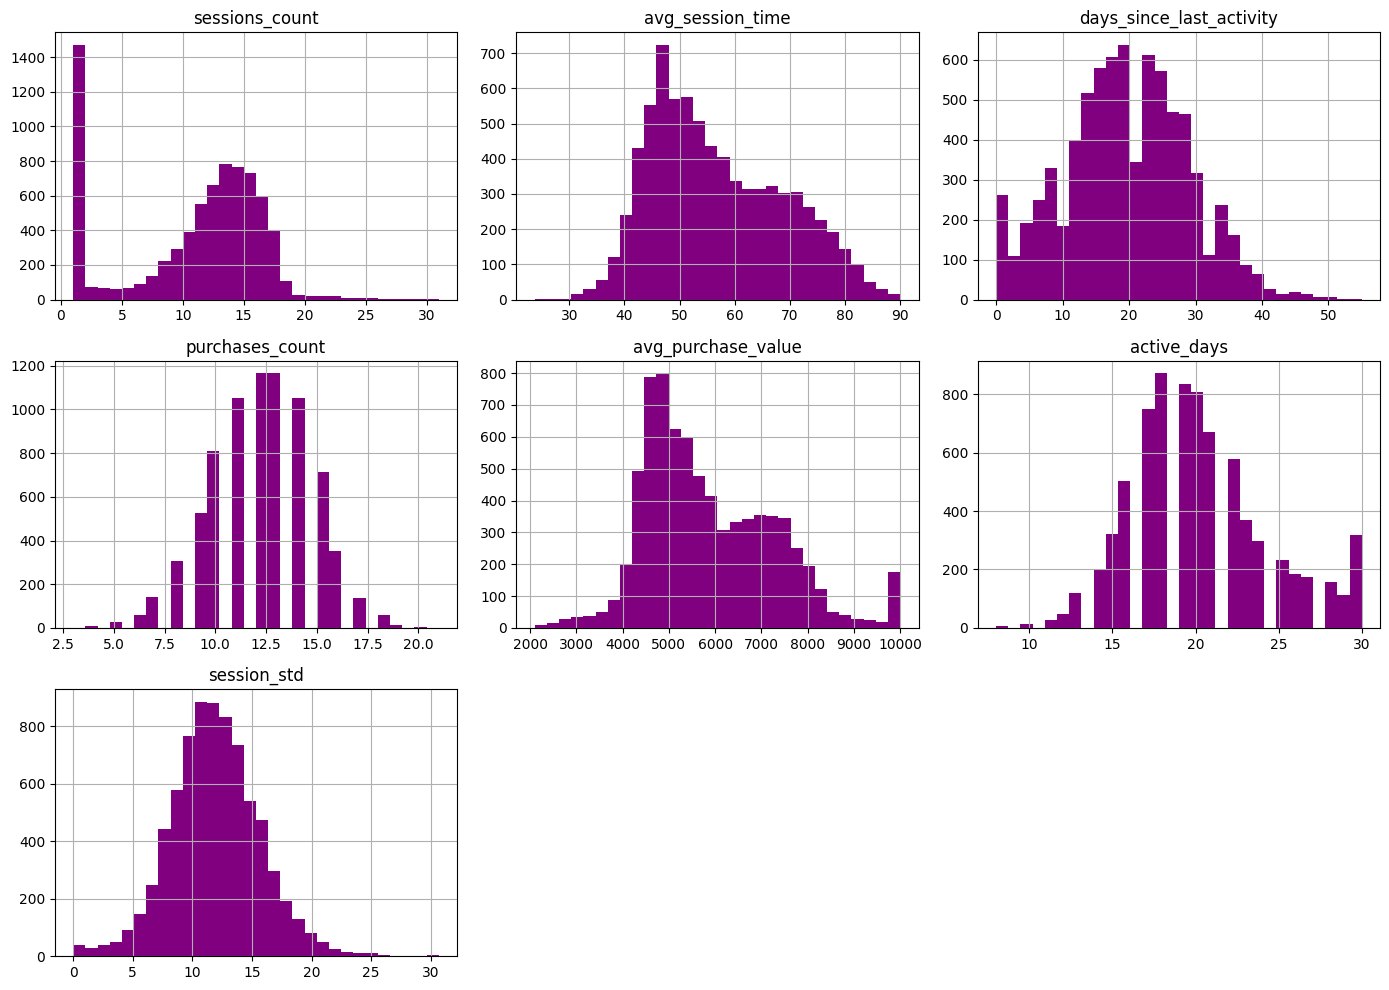

In [11]:
import matplotlib.pyplot as plt

features = [
    "sessions_count",
    "avg_session_time",
    "days_since_last_activity",
    "purchases_count",
    "avg_purchase_value",
    "active_days",
    "session_std"
]

train[features].hist(figsize=(14, 10), color='purple', bins=30)
plt.tight_layout()
plt.show()

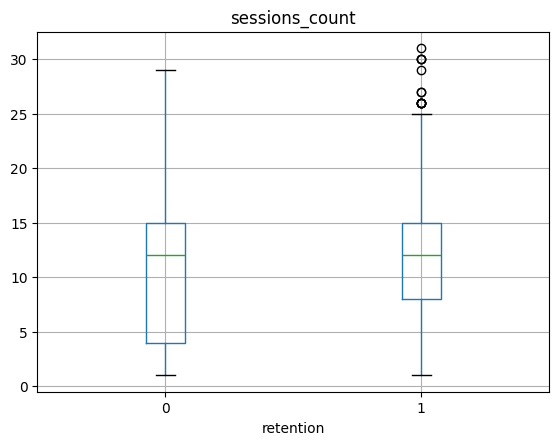

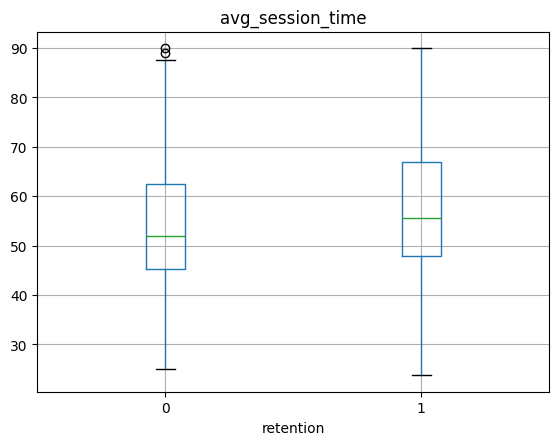

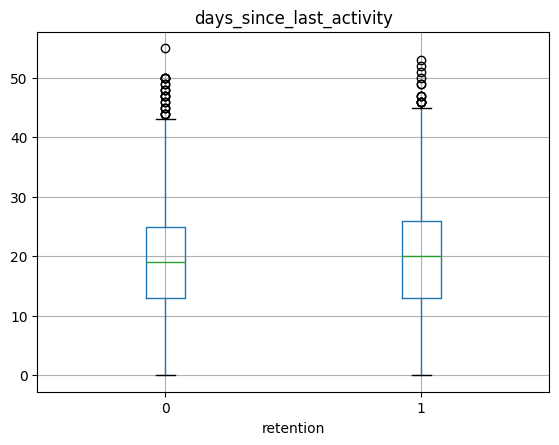

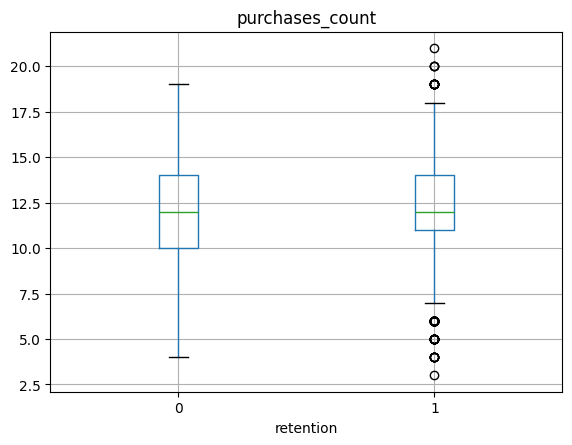

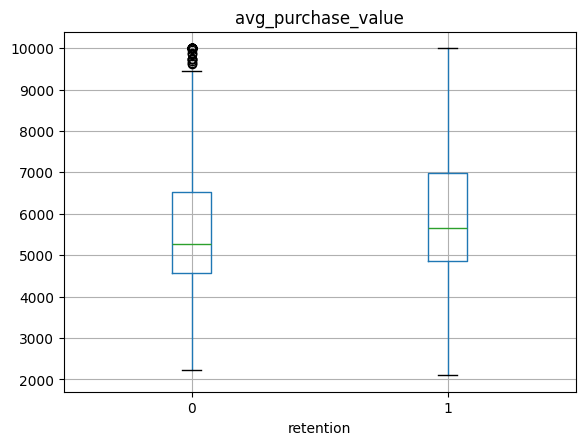

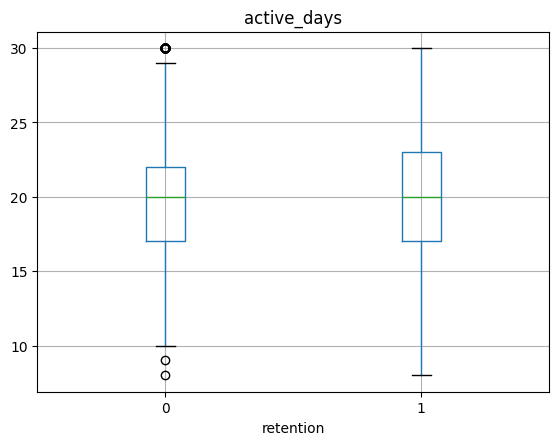

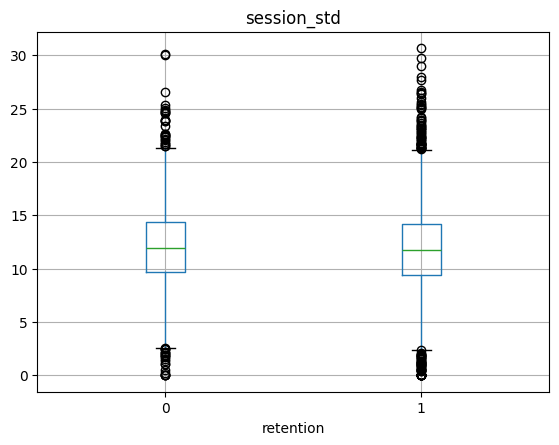

In [5]:
for feature in features:
    train.boxplot(column=feature, by="retention")
    plt.title(feature)
    plt.suptitle("")
    plt.xlabel("retention")
    plt.show()

In [6]:
train.groupby("retention")[features].agg(["mean", "median"])
train.drop(columns="id").corr()["retention"].sort_values(ascending=False)
pd.crosstab(
    train["is_weekend_user"],
    train["retention"],
    normalize="index"
)

retention,0,1
is_weekend_user,,
0,0.245134,0.754866
1,0.290535,0.709465


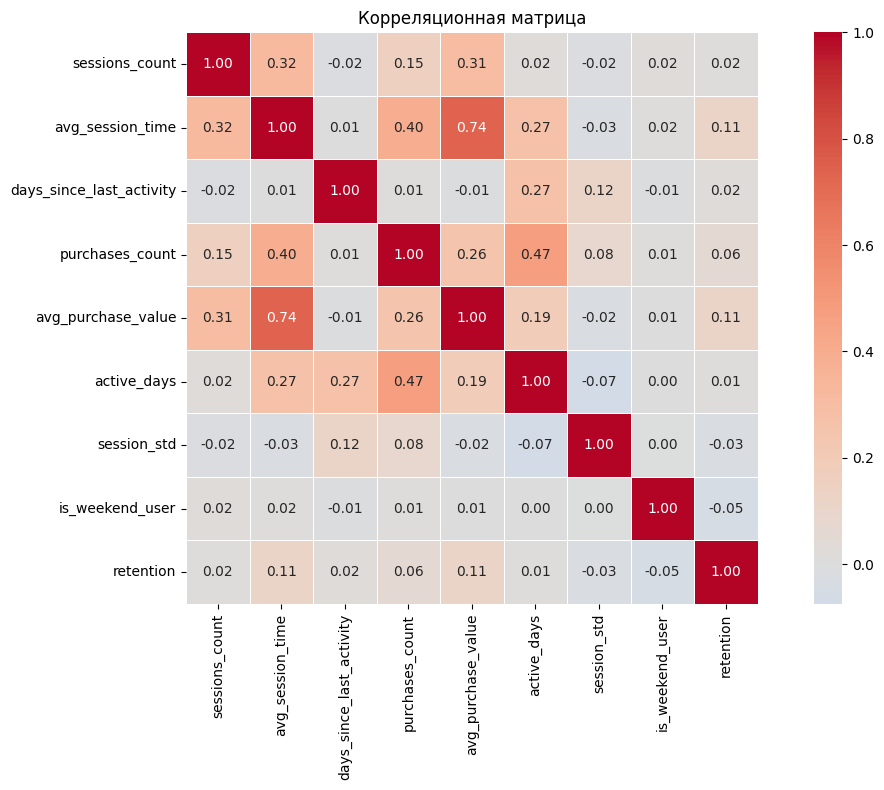

In [7]:
import seaborn as sns

corr = train.drop(columns="id").corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

In [8]:
train.assign(
    one_session=train["sessions_count"].eq(1)
).groupby("one_session")["retention"].agg(
    users="count",
    retention_rate="mean"
)

pd.crosstab(
    train["sessions_count"] == 1,
    train["retention"],
    normalize="index"
)

retention,0,1
sessions_count,,
False,0.258939,0.741061
True,0.304762,0.695238


In [12]:
temp = train.copy()

temp["sessions_per_active_day"] = (
    temp["sessions_count"] / temp["active_days"]
)

temp.groupby("retention")["sessions_per_active_day"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
retention,,,
0,0.535073,0.590909,0.340391
1,0.529809,0.565217,0.307492


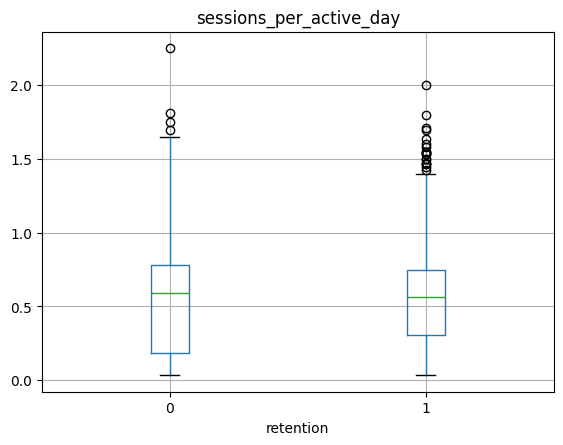

In [13]:
temp.boxplot(
    column="sessions_per_active_day",
    by="retention"
)
plt.suptitle("")
plt.show()

In [14]:
temp["purchases_per_session"] = (
    temp["purchases_count"] / temp["sessions_count"]
)

temp.groupby("retention")["purchases_per_session"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
retention,,,
0,3.187316,1.083333,4.018287
1,2.785623,1.090909,3.545430


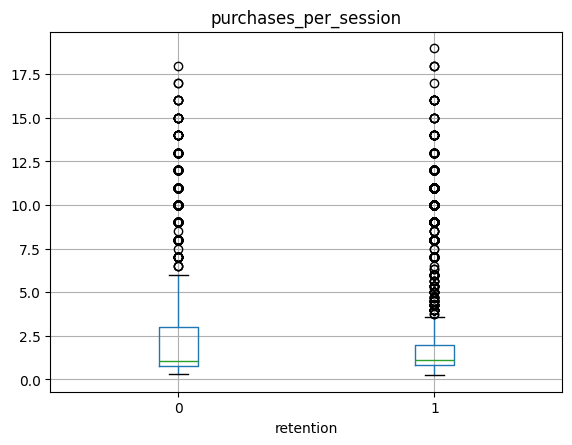

In [15]:
temp.boxplot(
    column="purchases_per_session",
    by="retention"
)

plt.suptitle("")
plt.show()

In [16]:
temp["purchases_per_active_day"] = (
    temp["purchases_count"] / temp["active_days"]
)

temp.groupby("retention")["purchases_per_active_day"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
retention,,,
0,0.603811,0.600000,0.128276
1,0.616899,0.608696,0.132316


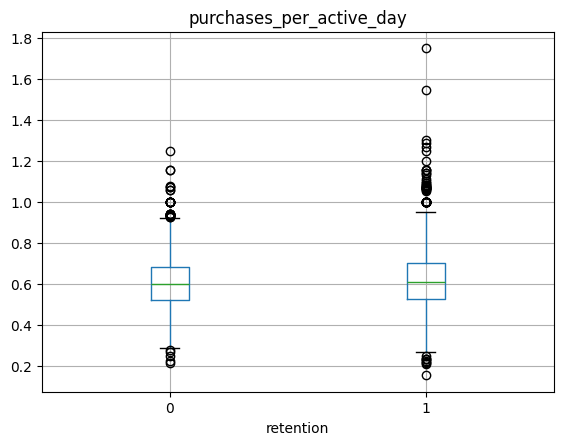

In [17]:
temp.boxplot(
    column="purchases_per_active_day",
    by="retention"
)

plt.suptitle("")
plt.show()

In [18]:
temp["total_purchase_value"] = (
    temp["purchases_count"] * temp["avg_purchase_value"]
)

temp.groupby("retention")["total_purchase_value"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
retention,,,
0,67625.823510,63121.630432,24168.124386
1,73908.823619,71194.778266,25445.651004


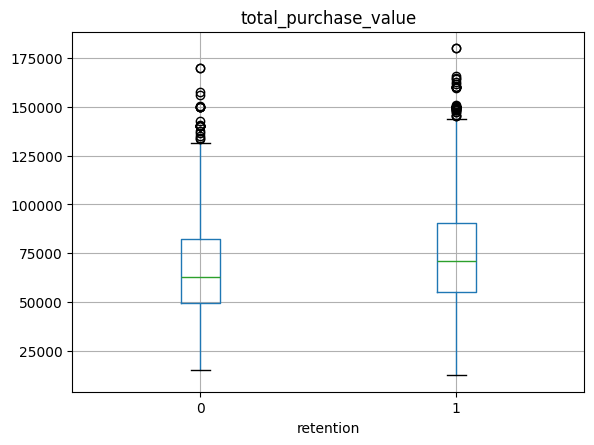

In [19]:
temp.boxplot(
    column="total_purchase_value",
    by="retention"
)

plt.suptitle("")
plt.show()

In [20]:
temp["session_cv"] = (
    temp["session_std"] / temp["avg_session_time"]
)

temp.groupby("retention")["session_cv"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
retention,,,
0,0.232562,0.220715,0.094298
1,0.214805,0.203442,0.085454


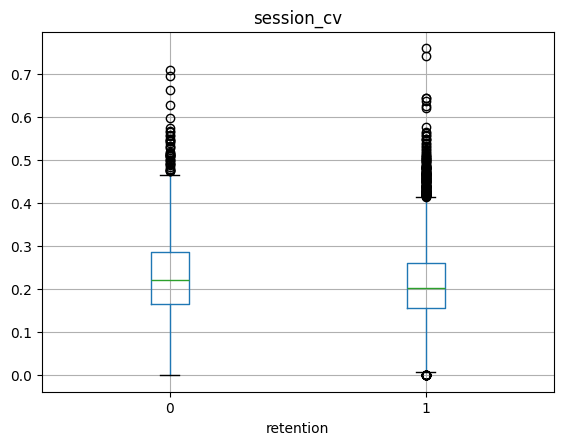

In [21]:
temp.boxplot(
    column="session_cv",
    by="retention"
)

plt.suptitle("")
plt.show()

In [22]:
temp["activity_recency"] = (
    temp["active_days"] /
    (temp["days_since_last_activity"] + 1)
)

temp.groupby("retention")["activity_recency"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
retention,,,
0,1.754025,1.0,2.948748
1,1.698314,1.0,2.952829


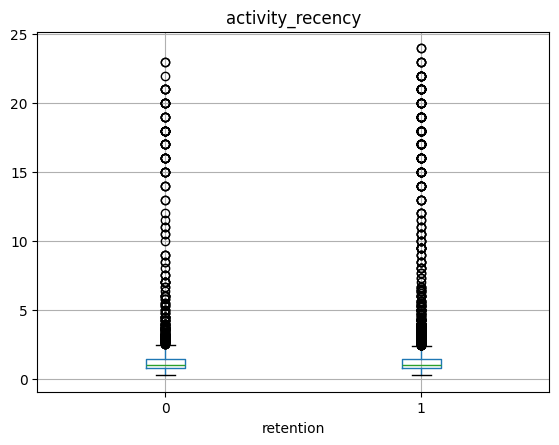

In [23]:
temp.boxplot(
    column="activity_recency",
    by="retention"
)

plt.suptitle("")
plt.show()

In [24]:
X = train.drop(columns=["id", "retention"])
y = train["retention"]

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_val_scaled)[:, 1]

auc = roc_auc_score(y_val, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.6235748501935552


In [28]:
X_h1 = train.drop(columns=["id", "retention"]).copy()

X_h1["is_one_session"] = (
    X_h1["sessions_count"] == 1
).astype(int)

In [29]:
X_train, X_val, y_train, y_val = train_test_split(
    X_h1,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

y_prob = model.predict_proba(X_val_scaled)[:, 1]

auc = roc_auc_score(y_val, y_prob)

print("ROC-AUC + is_one_session:", auc)

ROC-AUC + is_one_session: 0.629058915030138


In [31]:
X_h4 = train.drop(columns=["id", "retention"]).copy()

X_h4["total_purchase_value"] = (
    X_h4["purchases_count"] *
    X_h4["avg_purchase_value"]
)

In [32]:
X_train, X_val, y_train, y_val = train_test_split(
    X_h4,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

y_prob = model.predict_proba(X_val_scaled)[:, 1]

auc = roc_auc_score(y_val, y_prob)

print("ROC-AUC + total_purchase_value:", auc)

ROC-AUC + total_purchase_value: 0.6244895975111802


In [33]:
X_h5 = train.drop(columns=["id", "retention"]).copy()

X_h5["session_cv"] = (
    X_h5["session_std"] /
    X_h5["avg_session_time"]
)


In [34]:
X_train, X_val, y_train, y_val = train_test_split(
    X_h5,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

y_prob = model.predict_proba(X_val_scaled)[:, 1]

auc = roc_auc_score(y_val, y_prob)

print("ROC-AUC + session_cv:", auc)

ROC-AUC + session_cv: 0.6217674509041415


In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_base = train.drop(columns=["id", "retention"])
y = train["retention"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

scores_base = cross_val_score(
    pipeline,
    X_base,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Baseline folds:", scores_base)
print("Baseline CV mean:", scores_base.mean())
print("Baseline CV std:", scores_base.std())

Baseline folds: [0.58005365 0.59991073 0.58552004 0.60135356 0.59589314]
Baseline CV mean: 0.5925462237093424
Baseline CV std: 0.008347919848602628


In [36]:
X_h1 = X_base.copy()

X_h1["is_one_session"] = (
    X_h1["sessions_count"] == 1
).astype(int)

scores_h1 = cross_val_score(
    pipeline,
    X_h1,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("is_one_session folds:", scores_h1)
print("is_one_session CV mean:", scores_h1.mean())
print("is_one_session CV std:", scores_h1.std())

print("Delta:", scores_h1.mean() - scores_base.mean())

is_one_session folds: [0.5805751  0.60671389 0.59238285 0.60849699 0.58316404]
is_one_session CV mean: 0.5942665731939861
is_one_session CV std: 0.01159061305073001
Delta: 0.001720349484643724


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

X_base = train.drop(columns=["id", "retention"])
y = train["retention"]

tree = DecisionTreeClassifier(
    random_state=42
)

scores_tree = cross_val_score(
    tree,
    X_base,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Decision Tree folds:", scores_tree)
print("Decision Tree CV mean:", scores_tree.mean())
print("Decision Tree CV std:", scores_tree.std())

Decision Tree folds: [0.55307634 0.57183307 0.56341033 0.55399992 0.55211916]
Decision Tree CV mean: 0.5588877627685358
Decision Tree CV std: 0.007635606269388093


In [38]:
for depth in [2, 3, 4, 5, 6, 8, 10]:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        tree,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc"
    )

    print(
        f"depth={depth}: "
        f"CV={scores.mean():.4f}, "
        f"std={scores.std():.4f}"
    )

depth=2: CV=0.5824, std=0.0128
depth=3: CV=0.6022, std=0.0236
depth=4: CV=0.6188, std=0.0212
depth=5: CV=0.6231, std=0.0182
depth=6: CV=0.6286, std=0.0164
depth=8: CV=0.6195, std=0.0168
depth=10: CV=0.6100, std=0.0137


In [39]:
features = [
    "sessions_count",
    "avg_session_time",
    "days_since_last_activity",
    "purchases_count",
    "avg_purchase_value",
    "active_days",
    "session_std"
]

train[features].skew().sort_values(ascending=False)

avg_purchase_value          0.688361
active_days                 0.561592
avg_session_time            0.441930
session_std                 0.175379
days_since_last_activity    0.065760
purchases_count            -0.179127
sessions_count             -0.525392
dtype: float64

In [41]:
X_log = train.drop(columns=["id", "retention"]).copy()

X_log["avg_purchase_value"] = np.log1p(
    X_log["avg_purchase_value"]
)

X_log["active_days"] = np.log1p(
    X_log["active_days"]
)

scores_log = cross_val_score(
    pipeline,
    X_log,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Log folds:", scores_log)
print("Log CV mean:", scores_log.mean())
print("Log CV std:", scores_log.std())
print("Delta:", scores_log.mean() - scores_base.mean())

Log folds: [0.58110318 0.60215783 0.58795052 0.60278755 0.59952686]
Log CV mean: 0.5947051888558113
Log CV std: 0.008657426969600375
Delta: 0.0021589651464688497


In [42]:
X_log2 = train.drop(columns=["id", "retention"]).copy()

for col in [
    "avg_purchase_value",
    "active_days",
    "avg_session_time"
]:
    X_log2[col] = np.log1p(X_log2[col])

scores_log2 = cross_val_score(
    pipeline,
    X_log2,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Log2 folds:", scores_log2)
print("Log2 CV mean:", scores_log2.mean())
print("Log2 CV std:", scores_log2.std())
print("Delta vs baseline:", scores_log2.mean() - scores_base.mean())
print("Delta vs previous log:", scores_log2.mean() - scores_log.mean())

Log2 folds: [0.58264985 0.60421933 0.5870866  0.60559808 0.5981703 ]
Log2 CV mean: 0.5955448306761344
Log2 CV std: 0.009176382667360771
Delta vs baseline: 0.0029986069667919946
Delta vs previous log: 0.0008396418203231448


In [43]:
X_log_h1 = train.drop(columns=["id", "retention"]).copy()

for col in [
    "avg_purchase_value",
    "active_days",
    "avg_session_time"
]:
    X_log_h1[col] = np.log1p(X_log_h1[col])

X_log_h1["is_one_session"] = (
    X_log_h1["sessions_count"] == 1
).astype(int)

scores_log_h1 = cross_val_score(
    pipeline,
    X_log_h1,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Folds:", scores_log_h1)
print("CV mean:", scores_log_h1.mean())
print("CV std:", scores_log_h1.std())

print(
    "Delta vs baseline:",
    scores_log_h1.mean() - scores_base.mean()
)

print(
    "Delta vs log:",
    scores_log_h1.mean() - scores_log2.mean()
)

Folds: [0.58368833 0.61068884 0.59369752 0.61287407 0.58537703]
CV mean: 0.597265160138555
CV std: 0.012346817539050455
Delta vs baseline: 0.004718936429212617
Delta vs log: 0.0017203294624206222


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X_base = train.drop(columns=["id", "retention"])
y = train["retention"]

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

scores_rf = cross_val_score(
    rf,
    X_base,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Random Forest folds:", scores_rf)
print("Random Forest CV mean:", scores_rf.mean())
print("Random Forest CV std:", scores_rf.std())

Random Forest folds: [0.64534098 0.67914796 0.66291009 0.63204842 0.66628382]
Random Forest CV mean: 0.6571462519120862
Random Forest CV std: 0.01655329609184947


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

for depth in [1, 2, 3, 4, 5, 6, 8, 9, 10,11, 12, 13, 14, 15, 16, 17, None]:

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        rf,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"depth={depth}: "
        f"CV={scores.mean():.4f}, "
        f"std={scores.std():.4f}"
    )

depth=1: CV=0.5992, std=0.0140
depth=2: CV=0.6164, std=0.0150
depth=3: CV=0.6278, std=0.0153
depth=4: CV=0.6407, std=0.0138
depth=5: CV=0.6494, std=0.0122
depth=6: CV=0.6577, std=0.0115
depth=8: CV=0.6637, std=0.0131
depth=9: CV=0.6645, std=0.0144
depth=10: CV=0.6650, std=0.0155
depth=11: CV=0.6663, std=0.0153
depth=12: CV=0.6632, std=0.0174
depth=13: CV=0.6631, std=0.0179
depth=14: CV=0.6633, std=0.0171
depth=15: CV=0.6608, std=0.0171
depth=16: CV=0.6598, std=0.0165
depth=17: CV=0.6604, std=0.0160
depth=None: CV=0.6571, std=0.0166


In [48]:
for leaf in [1, 2, 3, 5, 8, 10, 15, 20]:

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=11,
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        rf,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"leaf={leaf}: "
        f"CV={scores.mean():.4f}, "
        f"std={scores.std():.4f}"
    )

leaf=1: CV=0.6663, std=0.0153
leaf=2: CV=0.6644, std=0.0147
leaf=3: CV=0.6663, std=0.0152
leaf=5: CV=0.6668, std=0.0176
leaf=8: CV=0.6655, std=0.0157
leaf=10: CV=0.6660, std=0.0164
leaf=15: CV=0.6642, std=0.0150
leaf=20: CV=0.6645, std=0.0152


In [49]:
for max_features in ["sqrt", "log2", 0.5, 0.75, 1.0]:

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=11,
        min_samples_leaf=1,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        rf,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"max_features={max_features}: "
        f"CV={scores.mean():.4f}, "
        f"std={scores.std():.4f}"
    )

max_features=sqrt: CV=0.6663, std=0.0153
max_features=log2: CV=0.6653, std=0.0160
max_features=0.5: CV=0.6669, std=0.0171
max_features=0.75: CV=0.6672, std=0.0158
max_features=1.0: CV=0.6641, std=0.0182


In [50]:
X_rf_fe = X_base.copy()

X_rf_fe["is_one_session"] = (
    X_rf_fe["sessions_count"] == 1
).astype(int)

rf_best = RandomForestClassifier(
    n_estimators=300,
    max_depth=11,
    min_samples_leaf=1,
    max_features=0.75,
    random_state=42,
    n_jobs=-1
)

scores_rf_fe = cross_val_score(
    rf_best,
    X_rf_fe,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("RF + is_one_session folds:", scores_rf_fe)
print("CV mean:", scores_rf_fe.mean())
print("CV std:", scores_rf_fe.std())
print("Delta:", scores_rf_fe.mean() - 0.6672)

RF + is_one_session folds: [0.65879704 0.69269793 0.67275909 0.6466667  0.6714445 ]
CV mean: 0.668473052436888
CV std: 0.015383021285354332
Delta: 0.0012730524368880225


In [51]:
X_rf_fe2 = X_base.copy()

X_rf_fe2["is_one_session"] = (
    X_rf_fe2["sessions_count"] == 1
).astype(int)

X_rf_fe2["total_purchase_value"] = (
    X_rf_fe2["purchases_count"] *
    X_rf_fe2["avg_purchase_value"]
)

scores_rf_fe2 = cross_val_score(
    rf_best,
    X_rf_fe2,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Folds:", scores_rf_fe2)
print("CV mean:", scores_rf_fe2.mean())
print("CV std:", scores_rf_fe2.std())
print(
    "Delta:",
    scores_rf_fe2.mean() - scores_rf_fe.mean()
)

Folds: [0.65694324 0.68022732 0.67742563 0.6436087  0.67155294]
CV mean: 0.6659515654006964
CV std: 0.013763575892272718
Delta: -0.002521487036191594


In [52]:
X_rf_fe3 = X_base.copy()

X_rf_fe3["is_one_session"] = (
    X_rf_fe3["sessions_count"] == 1
).astype(int)

X_rf_fe3["session_cv"] = (
    X_rf_fe3["session_std"] /
    X_rf_fe3["avg_session_time"]
)

In [53]:
rf_best = RandomForestClassifier(
    n_estimators=300,
    max_depth=11,
    min_samples_leaf=1,
    max_features=0.75,
    random_state=42,
    n_jobs=-1
)

scores_rf_fe3 = cross_val_score(
    rf_best,
    X_rf_fe3,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Folds:", scores_rf_fe3)
print("CV mean:", scores_rf_fe3.mean())
print("CV std:", scores_rf_fe3.std())

print(
    "Delta vs RF + is_one_session:",
    scores_rf_fe3.mean() - scores_rf_fe.mean()
)

Folds: [0.66018463 0.6885418  0.67066666 0.64023695 0.66790151]
CV mean: 0.6655063097539231
CV std: 0.015683498559641428
Delta vs RF + is_one_session: -0.002966742682964929


In [54]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

X_base = train.drop(columns=["id", "retention"])
y = train["retention"]

gb = GradientBoostingClassifier(
    random_state=42
)

scores_gb = cross_val_score(
    gb,
    X_base,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Gradient Boosting folds:", scores_gb)
print("Gradient Boosting CV mean:", scores_gb.mean())
print("Gradient Boosting CV std:", scores_gb.std())

Gradient Boosting folds: [0.64834152 0.67849725 0.64705999 0.638255   0.64770358]
Gradient Boosting CV mean: 0.6519714699282784
Gradient Boosting CV std: 0.013764248256499868


In [55]:
configs = [
    (0.20, 50),
    (0.10, 100),
    (0.05, 200),
    (0.03, 300),
    (0.02, 500),
    (0.01, 1000),
]

for lr, n_estimators in configs:
    gb = GradientBoostingClassifier(
        learning_rate=lr,
        n_estimators=n_estimators,
        max_depth=3,
        random_state=42
    )

    scores = cross_val_score(
        gb,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"lr={lr}, n={n_estimators}: "
        f"CV={scores.mean():.4f}, "
        f"std={scores.std():.4f}"
    )

lr=0.2, n=50: CV=0.6491, std=0.0111
lr=0.1, n=100: CV=0.6520, std=0.0138
lr=0.05, n=200: CV=0.6521, std=0.0110
lr=0.03, n=300: CV=0.6523, std=0.0121
lr=0.02, n=500: CV=0.6523, std=0.0113
lr=0.01, n=1000: CV=0.6524, std=0.0116


In [56]:
for depth in [1, 2, 3, 4, 5, 6]:

    gb = GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=200,
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        gb,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"depth={depth}: "
        f"CV={scores.mean():.4f}, "
        f"std={scores.std():.4f}"
    )

depth=1: CV=0.6128, std=0.0094
depth=2: CV=0.6400, std=0.0078
depth=3: CV=0.6521, std=0.0110
depth=4: CV=0.6570, std=0.0137
depth=5: CV=0.6588, std=0.0149
depth=6: CV=0.6498, std=0.0102


In [58]:
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score

catboost_model = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,  # не создаёт catboost_info
    thread_count=-1
)

scores_cb = cross_val_score(
    catboost_model,
    X_rf_fe,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,          # фолды обучаются последовательно
    error_score="raise"
)

print("CatBoost folds:", scores_cb)
print("CatBoost CV mean:", scores_cb.mean())
print("CatBoost CV std:", scores_cb.std())

CatBoost folds: [0.66854551 0.69610724 0.66576812 0.64205098 0.65003386]
CatBoost CV mean: 0.6645011418451556
CatBoost CV std: 0.018602256963931373


In [59]:
for depth in [3, 4, 5, 6, 7, 8, 9, 10]:

    cat = CatBoostClassifier(
        depth=depth,
        verbose=0,
        random_seed=42,
        allow_writing_files=False
    )

    scores = cross_val_score(
        cat,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"depth={depth}: "
        f"CV={scores.mean():.4f}, "
        f"std={scores.std():.4f}"
    )

depth=3: CV=0.6706, std=0.0131
depth=4: CV=0.6727, std=0.0141
depth=5: CV=0.6690, std=0.0169
depth=6: CV=0.6663, std=0.0200
depth=7: CV=0.6598, std=0.0187
depth=8: CV=0.6550, std=0.0205
depth=9: CV=0.6511, std=0.0220
depth=10: CV=0.6456, std=0.0189


In [61]:
for l2 in [0.1, 0.5, 1, 3, 5, 7, 10, 11, 12, 13, 14, 15, 20, 25, 30]:

    cat = CatBoostClassifier(
        depth=4,
        l2_leaf_reg=l2,
        verbose=0,
        random_seed=42,
        allow_writing_files=False
    )

    scores = cross_val_score(
        cat,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"l2={l2}: "
        f"CV={scores.mean():.4f}, "
        f"std={scores.std():.4f}"
    )

l2=0.1: CV=0.6703, std=0.0156
l2=0.5: CV=0.6701, std=0.0164
l2=1: CV=0.6718, std=0.0169
l2=3: CV=0.6730, std=0.0164
l2=5: CV=0.6685, std=0.0156
l2=7: CV=0.6711, std=0.0147
l2=10: CV=0.6714, std=0.0167
l2=11: CV=0.6721, std=0.0159
l2=12: CV=0.6713, std=0.0157
l2=13: CV=0.6693, std=0.0158
l2=14: CV=0.6706, std=0.0161
l2=15: CV=0.6720, std=0.0140
l2=20: CV=0.6709, std=0.0162
l2=25: CV=0.6706, std=0.0145
l2=30: CV=0.6712, std=0.0164


In [62]:
configs = [
    (0.10, 300),
    (0.05, 600),
    (0.03, 1000),
    (0.02, 1500),
    (0.01, 3000),
]

for lr, iterations in configs:

    cat = CatBoostClassifier(
        depth=4,
        l2_leaf_reg=3,
        learning_rate=lr,
        iterations=iterations,
        verbose=0,
        random_seed=42,
        allow_writing_files=False
    )

    scores = cross_val_score(
        cat,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"lr={lr}, iterations={iterations}: "
        f"CV={scores.mean():.4f}, "
        f"std={scores.std():.4f}"
    )

lr=0.1, iterations=300: CV=0.6668, std=0.0135
lr=0.05, iterations=600: CV=0.6684, std=0.0162
lr=0.03, iterations=1000: CV=0.6730, std=0.0164
lr=0.02, iterations=1500: CV=0.6727, std=0.0154
lr=0.01, iterations=3000: CV=0.6703, std=0.0149


In [63]:
X_cat_fe = X_base.copy()

X_cat_fe["is_one_session"] = (
    X_cat_fe["sessions_count"] == 1
).astype(int)

cat_best = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    verbose=0,
    random_seed=42,
    allow_writing_files=False
)

scores_cat_fe = cross_val_score(
    cat_best,
    X_cat_fe,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("CatBoost + is_one_session folds:", scores_cat_fe)
print("CV mean:", scores_cat_fe.mean())
print("CV std:", scores_cat_fe.std())
print(
    "Delta:",
    scores_cat_fe.mean() - scores_cat.mean()
)

CatBoost + is_one_session folds: [0.67510562 0.69503341 0.665693   0.65620526 0.65952315]
CV mean: 0.6703120849790594
CV std: 0.013934572314210577
Delta: nan


In [64]:
import numpy as np
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

oof_cat = np.zeros(len(train))
oof_rf = np.zeros(len(train))

X_cat = X_base.copy()

X_rf = X_base.copy()
X_rf["is_one_session"] = (
    X_rf["sessions_count"] == 1
).astype(int)

cat_best = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    verbose=0,
    random_seed=42,
    allow_writing_files=False
)

rf_best = RandomForestClassifier(
    n_estimators=300,
    max_depth=11,
    min_samples_leaf=1,
    max_features=0.75,
    random_state=42,
    n_jobs=-1
)

for train_idx, val_idx in cv.split(X_base, y):

    # CatBoost
    cat = clone(cat_best)

    cat.fit(
        X_cat.iloc[train_idx],
        y.iloc[train_idx]
    )

    oof_cat[val_idx] = cat.predict_proba(
        X_cat.iloc[val_idx]
    )[:, 1]

    # Random Forest
    rf = clone(rf_best)

    rf.fit(
        X_rf.iloc[train_idx],
        y.iloc[train_idx]
    )

    oof_rf[val_idx] = rf.predict_proba(
        X_rf.iloc[val_idx]
    )[:, 1]


print(
    "CatBoost OOF:",
    roc_auc_score(y, oof_cat)
)

print(
    "Random Forest OOF:",
    roc_auc_score(y, oof_rf)
)

CatBoost OOF: 0.6727295745744392
Random Forest OOF: 0.667968576635605


In [65]:
import numpy as np

corr = np.corrcoef(oof_cat, oof_rf)[0, 1]

print("Correlation:", corr)

Correlation: 0.8801822890474036


In [66]:
from sklearn.metrics import roc_auc_score

for cat_weight in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5,
                   0.6, 0.7, 0.8, 0.9, 1.0]:

    rf_weight = 1 - cat_weight

    blend = (
        cat_weight * oof_cat +
        rf_weight * oof_rf
    )

    score = roc_auc_score(y, blend)

    print(
        f"Cat={cat_weight:.1f}, "
        f"RF={rf_weight:.1f}: "
        f"ROC-AUC={score:.6f}"
    )

Cat=0.0, RF=1.0: ROC-AUC=0.667969
Cat=0.1, RF=0.9: ROC-AUC=0.670396
Cat=0.2, RF=0.8: ROC-AUC=0.672464
Cat=0.3, RF=0.7: ROC-AUC=0.674086
Cat=0.4, RF=0.6: ROC-AUC=0.675369
Cat=0.5, RF=0.5: ROC-AUC=0.676120
Cat=0.6, RF=0.4: ROC-AUC=0.676417
Cat=0.7, RF=0.3: ROC-AUC=0.676197
Cat=0.8, RF=0.2: ROC-AUC=0.675520
Cat=0.9, RF=0.1: ROC-AUC=0.674385
Cat=1.0, RF=0.0: ROC-AUC=0.672730


In [67]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

xgb = XGBClassifier(
    random_state=42,
    eval_metric="auc",
    n_jobs=-1
)

scores_xgb = cross_val_score(
    xgb,
    X_base,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("XGBoost folds:", scores_xgb)
print("XGBoost CV mean:", scores_xgb.mean())
print("XGBoost CV std:", scores_xgb.std())

XGBoost folds: [0.63200643 0.64844316 0.63620234 0.61017623 0.63132306]
XGBoost CV mean: 0.6316302450275278
XGBoost CV std: 0.012361947808283417


In [68]:
for depth in [1, 2, 3, 4, 5, 6, 8, 10]:

    xgb = XGBClassifier(
        max_depth=depth,
        random_state=42,
        eval_metric="auc",
        n_jobs=-1
    )

    scores = cross_val_score(
        xgb,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"depth={depth}: "
        f"CV={scores.mean():.4f}, "
        f"std={scores.std():.4f}"
    )

depth=1: CV=0.6227, std=0.0072
depth=2: CV=0.6483, std=0.0048
depth=3: CV=0.6486, std=0.0153
depth=4: CV=0.6464, std=0.0149
depth=5: CV=0.6346, std=0.0117
depth=6: CV=0.6316, std=0.0124
depth=8: CV=0.6288, std=0.0175
depth=10: CV=0.6230, std=0.0075


In [69]:
X_behavior = X_base.copy()

eps = 1e-6

# интенсивность использования
X_behavior["sessions_per_active_day"] = (
    X_behavior["sessions_count"] /
    (X_behavior["active_days"] + eps)
)

# покупки относительно использования
X_behavior["purchases_per_session"] = (
    X_behavior["purchases_count"] /
    (X_behavior["sessions_count"] + eps)
)

# покупки относительно активных дней
X_behavior["purchases_per_active_day"] = (
    X_behavior["purchases_count"] /
    (X_behavior["active_days"] + eps)
)

# примерный объём времени в приложении
X_behavior["total_session_time"] = (
    X_behavior["sessions_count"] *
    X_behavior["avg_session_time"]
)

In [70]:
cat_behavior = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    verbose=0,
    random_seed=42,
    allow_writing_files=False
)

scores_behavior = cross_val_score(
    cat_behavior,
    X_behavior,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Behavior FE folds:", scores_behavior)
print("CV mean:", scores_behavior.mean())
print("CV std:", scores_behavior.std())
print(
    "Delta vs CatBoost:",
    scores_behavior.mean() - 0.6727295745744392
)

Behavior FE folds: [0.67669869 0.70737366 0.66791579 0.64608559 0.65639841]
CV mean: 0.6708944272339917
CV std: 0.02097097576502616
Delta vs CatBoost: -0.0018351473404474294


In [71]:
features = {
    "sessions_per_active_day":
        X_base["sessions_count"] / (X_base["active_days"] + 1e-6),

    "purchases_per_session":
        X_base["purchases_count"] / (X_base["sessions_count"] + 1e-6),

    "purchases_per_active_day":
        X_base["purchases_count"] / (X_base["active_days"] + 1e-6),

    "total_session_time":
        X_base["sessions_count"] * X_base["avg_session_time"]
}

results = {}

for name, values in features.items():

    X_temp = X_base.copy()
    X_temp[name] = values

    scores = cross_val_score(
        cat_best,
        X_temp,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    results[name] = scores.mean()

    print(
        f"{name}: "
        f"CV={scores.mean():.6f}, "
        f"std={scores.std():.6f}, "
        f"delta={scores.mean() - 0.6727295745744392:+.6f}"
    )

sessions_per_active_day: CV=0.672272, std=0.021358, delta=-0.000457
purchases_per_session: CV=0.671254, std=0.017917, delta=-0.001476
purchases_per_active_day: CV=0.668466, std=0.015116, delta=-0.004263
total_session_time: CV=0.669147, std=0.019797, delta=-0.003582


In [72]:
import pandas as pd

features = [
    "sessions_count",
    "avg_session_time",
    "days_since_last_activity",
    "purchases_count",
    "avg_purchase_value",
    "active_days",
    "session_std"
]

for col in features:
    temp = train[[col, "retention"]].copy()

    # qcut пытается сделать группы примерно одинакового размера
    temp["bin"] = pd.qcut(
        temp[col],
        q=10,
        duplicates="drop"
    )

    stats = (
        temp.groupby("bin", observed=True)
        .agg(
            count=("retention", "size"),
            retention_rate=("retention", "mean"),
            value_mean=(col, "mean")
        )
        .reset_index()
    )

    print("\n", "=" * 70)
    print(col)
    print(stats.to_string(index=False))


sessions_count
         bin  count  retention_rate  value_mean
(0.999, 2.0]   1544        0.692358    1.047927
  (2.0, 9.0]    936        0.759615    7.155983
 (9.0, 11.0]    943        0.784730   10.584305
(11.0, 12.0]    663        0.722474   12.000000
(12.0, 13.0]    781        0.763124   13.000000
(13.0, 14.0]    767        0.739244   14.000000
(14.0, 15.0]    731        0.727770   15.000000
(15.0, 16.0]    591        0.734349   16.000000
(16.0, 31.0]    639        0.677621   18.189358

avg_session_time
             bin  count  retention_rate  value_mean
 (23.73, 42.972]    760        0.576316   39.843456
(42.972, 46.055]    759        0.682477   44.598363
(46.055, 48.375]    760        0.734211   47.166820
(48.375, 51.254]    759        0.725955   49.842069
(51.254, 54.467]    760        0.738158   52.875844
(54.467, 58.398]    759        0.744401   56.374208
(58.398, 63.418]    759        0.756258   60.805826
(63.418, 68.685]    760        0.794737   66.050153
  (68.685, 74.5]  

In [73]:
temp = train[["id", "retention"]].copy()

temp["id_bin"] = pd.qcut(
    temp["id"],
    q=20,
    duplicates="drop"
)

id_stats = (
    temp.groupby("id_bin", observed=True)
    .agg(
        count=("retention", "size"),
        retention_rate=("retention", "mean"),
        id_mean=("id", "mean")
    )
    .reset_index()
)

print(id_stats.to_string(index=False))

print(
    "\nCorrelation:",
    train["id"].corr(train["retention"])
)

           id_bin  count  retention_rate     id_mean
   (0.999, 498.7]    380        0.771053  245.747368
   (498.7, 990.4]    380        0.776316  746.165789
  (990.4, 1460.1]    380        0.668421 1225.073684
 (1460.1, 1959.8]    379        0.741425 1714.781003
 (1959.8, 2461.5]    380        0.742105 2210.863158
 (2461.5, 2990.2]    380        0.718421 2733.192105
 (2990.2, 3511.9]    379        0.746702 3255.195251
 (3511.9, 4014.6]    380        0.707895 3764.252632
 (4014.6, 4526.3]    380        0.731579 4263.931579
 (4526.3, 5042.0]    380        0.710526 4779.500000
 (5042.0, 5573.1]    379        0.725594 5318.203166
 (5573.1, 6060.4]    380        0.755263 5821.263158
 (6060.4, 6581.1]    380        0.731579 6323.536842
 (6581.1, 7092.8]    379        0.722955 6832.984169
 (7092.8, 7580.5]    380        0.747368 7331.910526
 (7580.5, 8098.2]    380        0.707895 7842.931579
 (8098.2, 8588.9]    379        0.709763 8346.353562
 (8588.9, 9112.2]    380        0.728947 8853.

In [74]:
from sklearn.metrics import roc_auc_score

print(
    "ID ROC-AUC:",
    roc_auc_score(
        train["retention"],
        train["id"]
    )
)

ID ROC-AUC: 0.49705810429672725


In [75]:
base_score = 0.6727295745744392

features = X_base.columns

for col in features:

    X_temp = X_base.drop(columns=[col])

    scores = cross_val_score(
        cat_best,
        X_temp,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"drop {col}: "
        f"CV={scores.mean():.6f}, "
        f"std={scores.std():.6f}, "
        f"delta={scores.mean() - base_score:+.6f}"
    )

drop sessions_count: CV=0.620998, std=0.009756, delta=-0.051732
drop avg_session_time: CV=0.667930, std=0.016262, delta=-0.004799
drop days_since_last_activity: CV=0.670938, std=0.017170, delta=-0.001792
drop purchases_count: CV=0.667939, std=0.017765, delta=-0.004791
drop avg_purchase_value: CV=0.659373, std=0.020095, delta=-0.013357
drop active_days: CV=0.638289, std=0.015316, delta=-0.034441
drop session_std: CV=0.672369, std=0.013831, delta=-0.000360
drop is_weekend_user: CV=0.642146, std=0.011958, delta=-0.030583


In [76]:
for weekend in [0, 1]:

    subset = train[
        train["is_weekend_user"] == weekend
    ].copy()

    print("\n" + "=" * 60)
    print("is_weekend_user =", weekend)
    print("N =", len(subset))
    print("Retention =", subset["retention"].mean())

    subset["sessions_bin"] = pd.qcut(
        subset["sessions_count"],
        q=6,
        duplicates="drop"
    )

    stats = (
        subset.groupby("sessions_bin", observed=True)
        ["retention"]
        .agg(["count", "mean"])
    )

    print("\nsessions_count:")
    print(stats)

    subset["active_days_bin"] = pd.qcut(
        subset["active_days"],
        q=6,
        duplicates="drop"
    )

    stats = (
        subset.groupby("active_days_bin", observed=True)
        ["retention"]
        .agg(["count", "mean"])
    )

    print("\nactive_days:")
    print(stats)


is_weekend_user = 0
N = 3802
Retention = 0.7548658600736454

sessions_count:
               count      mean
sessions_bin                  
(0.999, 10.0]   1267  0.752960
(10.0, 12.0]     791  0.805310
(12.0, 14.0]     789  0.773131
(14.0, 15.0]     373  0.723861
(15.0, 30.0]     582  0.685567

active_days:
                 count      mean
active_days_bin                 
(7.999, 17.0]      998  0.768537
(17.0, 18.0]       462  0.731602
(18.0, 20.0]       814  0.738329
(20.0, 21.0]       332  0.710843
(21.0, 24.0]       592  0.771959
(24.0, 30.0]       604  0.779801

is_weekend_user = 1
N = 3793
Retention = 0.7094648035855523

sessions_count:
               count      mean
sessions_bin                  
(0.999, 10.0]   1394  0.687948
(10.0, 12.0]     634  0.708202
(12.0, 14.0]     759  0.728590
(14.0, 16.0]     668  0.742515
(16.0, 31.0]     338  0.692308

active_days:
                 count      mean
active_days_bin                 
(7.999, 17.0]      992  0.704637
(17.0, 18.0]       

In [77]:
X_inter = X_base.copy()

X_inter["sessions_weekend_interaction"] = (
    X_inter["sessions_count"] *
    X_inter["is_weekend_user"]
)

scores_inter = cross_val_score(
    cat_best,
    X_inter,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Interaction folds:", scores_inter)
print("CV mean:", scores_inter.mean())
print("CV std:", scores_inter.std())
print(
    "Delta:",
    scores_inter.mean() - 0.6727295745744392
)

Interaction folds: [0.67167642 0.69916082 0.67183771 0.64915463 0.65969355]
CV mean: 0.67030462572393
CV std: 0.016714241257346538
Delta: -0.0024249488505091454


In [78]:
for rs in [0, 0.5, 1, 2, 3, 5, 10]:

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.03,
        depth=4,
        l2_leaf_reg=3,
        random_strength=rs,
        verbose=0,
        random_seed=42,
        allow_writing_files=False
    )

    scores = cross_val_score(
        model,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"random_strength={rs}: "
        f"CV={scores.mean():.6f}, "
        f"std={scores.std():.6f}"
    )

random_strength=0: CV=0.667767, std=0.016217
random_strength=0.5: CV=0.669817, std=0.016453
random_strength=1: CV=0.672985, std=0.016355
random_strength=2: CV=0.671127, std=0.014168
random_strength=3: CV=0.672944, std=0.016066
random_strength=5: CV=0.670196, std=0.013869
random_strength=10: CV=0.672183, std=0.016444


In [79]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score

seeds = [42, 123, 777, 2026, 3407]

cat_means = []
rf_means = []

for seed in seeds:

    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    # CatBoost
    cat_scores = cross_val_score(
        cat_best,
        X_base,
        y,
        cv=cv_seed,
        scoring="roc_auc",
        n_jobs=-1
    )

    # RF использует is_one_session
    rf_scores = cross_val_score(
        rf_best,
        X_rf,
        y,
        cv=cv_seed,
        scoring="roc_auc",
        n_jobs=-1
    )

    cat_means.append(cat_scores.mean())
    rf_means.append(rf_scores.mean())

    print(
        f"seed={seed}: "
        f"Cat={cat_scores.mean():.6f}, "
        f"RF={rf_scores.mean():.6f}"
    )

print("\nCAT")
print("mean:", np.mean(cat_means))
print("std between splits:", np.std(cat_means))
print("min/max:", min(cat_means), max(cat_means))

print("\nRF")
print("mean:", np.mean(rf_means))
print("std between splits:", np.std(rf_means))
print("min/max:", min(rf_means), max(rf_means))

seed=42: Cat=0.672985, RF=0.668473
seed=123: Cat=0.669052, RF=0.668199
seed=777: Cat=0.664200, RF=0.665974
seed=2026: Cat=0.671470, RF=0.665189
seed=3407: Cat=0.664064, RF=0.666337

CAT
mean: 0.6683543159290017
std between splits: 0.003668763814386021
min/max: 0.6640642429858049 0.6729851564068492

RF
mean: 0.6668343967006055
std between splits: 0.0012839228266966329
min/max: 0.6651888406106725 0.668473052436888


In [80]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
import numpy as np

blend_scores = []
cat_oof_scores = []
rf_oof_scores = []

for seed in seeds:

    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    oof_cat_seed = np.zeros(len(y))
    oof_rf_seed = np.zeros(len(y))

    for train_idx, val_idx in cv_seed.split(X_base, y):

        # CatBoost
        cat = clone(cat_best)

        cat.fit(
            X_base.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_cat_seed[val_idx] = cat.predict_proba(
            X_base.iloc[val_idx]
        )[:, 1]

        # Random Forest
        rf = clone(rf_best)

        rf.fit(
            X_rf.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_rf_seed[val_idx] = rf.predict_proba(
            X_rf.iloc[val_idx]
        )[:, 1]

    cat_auc = roc_auc_score(y, oof_cat_seed)
    rf_auc = roc_auc_score(y, oof_rf_seed)

    blend = (
        0.6 * oof_cat_seed +
        0.4 * oof_rf_seed
    )

    blend_auc = roc_auc_score(y, blend)

    cat_oof_scores.append(cat_auc)
    rf_oof_scores.append(rf_auc)
    blend_scores.append(blend_auc)

    print(
        f"seed={seed}: "
        f"Cat={cat_auc:.6f}, "
        f"RF={rf_auc:.6f}, "
        f"Blend={blend_auc:.6f}, "
        f"delta_vs_cat={blend_auc-cat_auc:+.6f}"
    )

print("\nBLEND")
print("mean:", np.mean(blend_scores))
print("std:", np.std(blend_scores))
print("min/max:", min(blend_scores), max(blend_scores))

print(
    "mean delta vs Cat:",
    np.mean(np.array(blend_scores) - np.array(cat_oof_scores))
)

seed=42: Cat=0.672730, RF=0.667969, Blend=0.676417, delta_vs_cat=+0.003688
seed=123: Cat=0.668624, RF=0.667830, Blend=0.673906, delta_vs_cat=+0.005282
seed=777: Cat=0.663493, RF=0.664713, Blend=0.669706, delta_vs_cat=+0.006212
seed=2026: Cat=0.670732, RF=0.664458, Blend=0.674062, delta_vs_cat=+0.003330
seed=3407: Cat=0.663752, RF=0.665973, Blend=0.670291, delta_vs_cat=+0.006539

BLEND
mean: 0.6728763334056518
std: 0.002519628237872683
min/max: 0.6697056353799825 0.676417199639928
mean delta vs Cat: 0.0050100459072232924


In [83]:
from scipy.stats import ks_2samp
import pandas as pd

features = [
    "sessions_count",
    "avg_session_time",
    "days_since_last_activity",
    "purchases_count",
    "avg_purchase_value",
    "active_days",
    "session_std",
    "is_weekend_user"
]

rows = []

for col in features:

    train_col = train[col]
    test_col = test[col]

    ks_stat, p_value = ks_2samp(
        train_col,
        test_col
    )

    rows.append({
        "feature": col,

        "train_mean": train_col.mean(),
        "test_mean": test_col.mean(),

        "train_std": train_col.std(),
        "test_std": test_col.std(),

        "train_min": train_col.min(),
        "test_min": test_col.min(),

        "train_max": train_col.max(),
        "test_max": test_col.max(),

        "KS": ks_stat,
        "p_value": p_value
    })

shift_df = pd.DataFrame(rows)

print(
    shift_df.sort_values(
        "KS",
        ascending=False
    ).to_string(index=False)
)

                 feature  train_mean   test_mean   train_std    test_std   train_min    test_min    train_max     test_max       KS  p_value
          sessions_count   10.426333   10.606240    5.643471    5.545132    1.000000    1.000000    31.000000    30.000000 0.018383 0.534259
      avg_purchase_value 5870.966510 5899.702341 1429.775977 1486.855211 2097.949638 1997.375798 10000.000000 10000.000000 0.017634 0.587801
             active_days   20.233180   20.291469    4.144513    4.201037    8.000000    9.000000    30.000000    30.000000 0.016957 0.637072
days_since_last_activity   19.565240   19.821880    9.334608    9.307654    0.000000    0.000000    55.000000    60.000000 0.016384 0.680098
             session_std   11.914057   11.927884    3.758870    3.779952    0.000000    0.000000    30.661213    29.702299 0.016254 0.689549
         purchases_count   12.149704   12.144155    2.442620    2.367165    3.000000    1.000000    21.000000    19.000000 0.015706 0.729639
        avg_s

In [84]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nWeekend:")
print("train:", train["is_weekend_user"].value_counts(normalize=True))
print("test:")
print(test["is_weekend_user"].value_counts(normalize=True))

Train shape: (7595, 10)
Test shape: (2532, 9)

Weekend:
train: is_weekend_user
0    0.500592
1    0.499408
Name: proportion, dtype: float64
test:
is_weekend_user
1    0.504344
0    0.495656
Name: proportion, dtype: float64


In [85]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier

model_seeds = [42, 123, 777, 2026, 3407]

cv_final = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_cat_single = np.zeros(len(y))
oof_cat_ensemble = np.zeros(len(y))

for train_idx, val_idx in cv_final.split(X_base, y):

    X_train = X_base.iloc[train_idx]
    X_val = X_base.iloc[val_idx]

    y_train = y.iloc[train_idx]

    fold_predictions = []

    for model_seed in model_seeds:

        model = CatBoostClassifier(
            iterations=1000,
            learning_rate=0.03,
            depth=4,
            l2_leaf_reg=3,
            random_strength=1,
            random_seed=model_seed,
            verbose=0,
            allow_writing_files=False
        )

        model.fit(X_train, y_train)

        pred = model.predict_proba(X_val)[:, 1]
        fold_predictions.append(pred)

        # сохраняем обычную модель seed=42 для сравнения
        if model_seed == 42:
            oof_cat_single[val_idx] = pred

    # усредняем 5 CatBoost
    oof_cat_ensemble[val_idx] = np.mean(
        fold_predictions,
        axis=0
    )

single_auc = roc_auc_score(
    y,
    oof_cat_single
)

ensemble_auc = roc_auc_score(
    y,
    oof_cat_ensemble
)

print("Single CatBoost:", single_auc)
print("5-seed CatBoost:", ensemble_auc)
print("Delta:", ensemble_auc - single_auc)

Single CatBoost: 0.6727295745744392
5-seed CatBoost: 0.6720691598339822
Delta: -0.0006604147404569716


In [86]:
import numpy as np
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

seeds = [42, 123, 777, 2026, 3407]

# сюда сохраним OOF каждого разбиения
all_oof = {}

for seed in seeds:

    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    oof_cat = np.zeros(len(y))
    oof_rf = np.zeros(len(y))

    for train_idx, val_idx in cv_seed.split(X_base, y):

        # CatBoost
        cat = clone(cat_best)

        cat.fit(
            X_base.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_cat[val_idx] = cat.predict_proba(
            X_base.iloc[val_idx]
        )[:, 1]

        # Random Forest
        rf = clone(rf_best)

        rf.fit(
            X_rf.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_rf[val_idx] = rf.predict_proba(
            X_rf.iloc[val_idx]
        )[:, 1]

    all_oof[seed] = {
        "cat": oof_cat,
        "rf": oof_rf
    }

    print(f"seed={seed} готов")

seed=42 готов
seed=123 готов
seed=777 готов
seed=2026 готов
seed=3407 готов


In [87]:
weights = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for cat_weight in weights:

    rf_weight = 1 - cat_weight

    scores = []

    for seed in seeds:

        cat_pred = all_oof[seed]["cat"]
        rf_pred = all_oof[seed]["rf"]

        blend = (
            cat_weight * cat_pred +
            rf_weight * rf_pred
        )

        auc = roc_auc_score(y, blend)
        scores.append(auc)

    print(
        f"Cat={cat_weight:.1f}, "
        f"RF={rf_weight:.1f}: "
        f"mean={np.mean(scores):.6f}, "
        f"std={np.std(scores):.6f}, "
        f"min={np.min(scores):.6f}, "
        f"max={np.max(scores):.6f}"
    )

Cat=0.3, RF=0.7: mean=0.671461, std=0.001747, min=0.669218, max=0.674086
Cat=0.4, RF=0.6: mean=0.672403, std=0.002004, min=0.669826, max=0.675369
Cat=0.5, RF=0.5: mean=0.672880, std=0.002246, min=0.669982, max=0.676120
Cat=0.6, RF=0.4: mean=0.672876, std=0.002520, min=0.669706, max=0.676417
Cat=0.7, RF=0.3: mean=0.672341, std=0.002804, min=0.668893, max=0.676197
Cat=0.8, RF=0.2: mean=0.671309, std=0.003136, min=0.667561, max=0.675520
Cat=0.9, RF=0.1: mean=0.669803, std=0.003450, min=0.665722, max=0.674385


In [88]:
temp = train[
    ["sessions_count", "active_days", "retention"]
].copy()

temp["sessions_bin"] = pd.qcut(
    temp["sessions_count"],
    q=5,
    duplicates="drop"
)

temp["active_days_bin"] = pd.qcut(
    temp["active_days"],
    q=5,
    duplicates="drop"
)

interaction_table = pd.pivot_table(
    temp,
    values="retention",
    index="sessions_bin",
    columns="active_days_bin",
    aggfunc="mean",
    observed=True
)

count_table = pd.pivot_table(
    temp,
    values="retention",
    index="sessions_bin",
    columns="active_days_bin",
    aggfunc="count",
    observed=True
)

print("RETENTION RATE:")
print(interaction_table.round(3))

print("\nCOUNT:")
print(count_table)

RETENTION RATE:
active_days_bin  (7.999, 17.0]  (17.0, 19.0]  (19.0, 21.0]  (21.0, 23.0]  \
sessions_bin                                                               
(0.999, 2.0]             0.784         0.801         0.547         0.430   
(2.0, 11.0]              0.721         0.768         0.737         0.775   
(11.0, 13.0]             0.753         0.702         0.725         0.758   
(13.0, 15.0]             0.711         0.668         0.729         0.830   
(15.0, 31.0]             0.668         0.714         0.712         0.791   

active_days_bin  (23.0, 30.0]  
sessions_bin                   
(0.999, 2.0]            0.494  
(2.0, 11.0]             0.810  
(11.0, 13.0]            0.799  
(13.0, 15.0]            0.812  
(15.0, 31.0]            0.694  

COUNT:
active_days_bin  (7.999, 17.0]  (17.0, 19.0]  (19.0, 21.0]  (21.0, 23.0]  \
sessions_bin                                                               
(0.999, 2.0]               749           282           170         

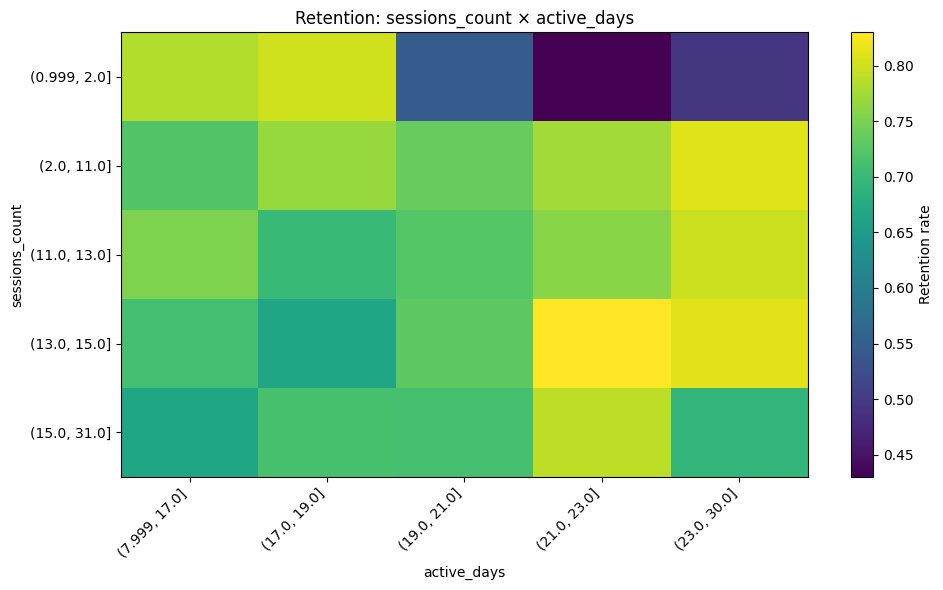

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.imshow(
    interaction_table,
    aspect="auto"
)

plt.colorbar(label="Retention rate")

plt.xticks(
    range(len(interaction_table.columns)),
    interaction_table.columns.astype(str),
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(interaction_table.index)),
    interaction_table.index.astype(str)
)

plt.xlabel("active_days")
plt.ylabel("sessions_count")
plt.title("Retention: sessions_count × active_days")

plt.tight_layout()
plt.show()

In [90]:
X_joint = X_base.copy()

X_joint["sessions_group"] = pd.cut(
    X_joint["sessions_count"],
    bins=[0, 2, 11, 13, 15, np.inf],
    labels=False
)

X_joint["active_days_group"] = pd.cut(
    X_joint["active_days"],
    bins=[0, 17, 19, 21, 23, np.inf],
    labels=False
)

X_joint["sessions_active_group"] = (
    X_joint["sessions_group"] * 5 +
    X_joint["active_days_group"]
)

X_joint["sessions_active_group"] = (
    X_joint["sessions_active_group"]
    .astype(str)
)

In [91]:
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score

cat_joint = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    random_strength=1,
    verbose=0,
    random_seed=42,
    allow_writing_files=False
)

cat_features = ["sessions_active_group"]

scores_joint = cross_val_score(
    cat_joint,
    X_joint,
    y,
    cv=cv,
    scoring="roc_auc",
    params={
        "cat_features": cat_features
    },
    n_jobs=-1
)

print("Joint folds:", scores_joint)
print("CV mean:", scores_joint.mean())
print("CV std:", scores_joint.std())
print(
    "Delta:",
    scores_joint.mean() - 0.6727295745744392
)

Joint folds: [0.68203251 0.69817095 0.66769484 0.65814302 0.65371848]
CV mean: 0.6719519581991255
CV std: 0.016311483122254153
Delta: -0.0007776163753137055


In [92]:
X_no_id = train.drop(columns=["retention", "id"])
X_with_id = train.drop(columns=["retention"])

seeds = [42, 123, 777, 2026, 3407]

without_id = []
with_id = []

for seed in seeds:

    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    score_without = cross_val_score(
        cat_best,
        X_no_id,
        y,
        cv=cv_seed,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    score_with = cross_val_score(
        cat_best,
        X_with_id,
        y,
        cv=cv_seed,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    without_id.append(score_without)
    with_id.append(score_with)

    print(
        f"seed={seed}: "
        f"without_id={score_without:.6f}, "
        f"with_id={score_with:.6f}, "
        f"delta={score_with-score_without:+.6f}"
    )

print("\nWITHOUT ID:", np.mean(without_id))
print("WITH ID:", np.mean(with_id))
print(
    "MEAN DELTA:",
    np.mean(np.array(with_id) - np.array(without_id))
)

seed=42: without_id=0.672985, with_id=0.664552, delta=-0.008433
seed=123: without_id=0.669052, with_id=0.661822, delta=-0.007230
seed=777: without_id=0.664200, with_id=0.659598, delta=-0.004603
seed=2026: without_id=0.671470, with_id=0.668783, delta=-0.002687
seed=3407: without_id=0.664064, with_id=0.663492, delta=-0.000572

WITHOUT ID: 0.6683543159290017
WITH ID: 0.6636492767299702
MEAN DELTA: -0.004705039199031469


In [93]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import cross_val_score

extra = ExtraTreesClassifier(
    n_estimators=800,
    max_depth=11,
    min_samples_leaf=3,
    max_features=0.75,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    extra,
    X_base,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("ExtraTrees folds:", scores)
print("ExtraTrees CV mean:", scores.mean())
print("ExtraTrees CV std:", scores.std())

ExtraTrees folds: [0.66824501 0.70382515 0.67568672 0.63743526 0.66084651]
ExtraTrees CV mean: 0.6692077305592944
ExtraTrees CV std: 0.021543766957728836


In [94]:
import numpy as np
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

oof_extra = np.zeros(len(y))

for train_idx, val_idx in cv.split(X_base, y):

    model = clone(extra)

    model.fit(
        X_base.iloc[train_idx],
        y.iloc[train_idx]
    )

    oof_extra[val_idx] = model.predict_proba(
        X_base.iloc[val_idx]
    )[:, 1]

print(
    "ExtraTrees OOF:",
    roc_auc_score(y, oof_extra)
)

print(
    "Correlation Cat-Extra:",
    np.corrcoef(oof_cat, oof_extra)[0, 1]
)

print(
    "Correlation RF-Extra:",
    np.corrcoef(oof_rf, oof_extra)[0, 1]
)

print(
    "Correlation Cat-RF:",
    np.corrcoef(oof_cat, oof_rf)[0, 1]
)

ExtraTrees OOF: 0.6688509862105049
Correlation Cat-Extra: 0.8556668301978202
Correlation RF-Extra: 0.8943863022371595
Correlation Cat-RF: 0.8704037599337893


In [95]:
base_blend = (
    0.5 * oof_cat +
    0.5 * oof_rf
)

print(
    "Cat + RF:",
    roc_auc_score(y, base_blend)
)

for extra_weight in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:

    remaining = 1 - extra_weight

    blend = (
        remaining * 0.5 * oof_cat +
        remaining * 0.5 * oof_rf +
        extra_weight * oof_extra
    )

    print(
        f"Extra={extra_weight:.2f}, "
        f"Cat={remaining*0.5:.3f}, "
        f"RF={remaining*0.5:.3f}: "
        f"AUC={roc_auc_score(y, blend):.6f}"
    )

Cat + RF: 0.67072817311601
Extra=0.05, Cat=0.475, RF=0.475: AUC=0.671319
Extra=0.10, Cat=0.450, RF=0.450: AUC=0.671814
Extra=0.15, Cat=0.425, RF=0.425: AUC=0.672296
Extra=0.20, Cat=0.400, RF=0.400: AUC=0.672740
Extra=0.25, Cat=0.375, RF=0.375: AUC=0.673099
Extra=0.30, Cat=0.350, RF=0.350: AUC=0.673395


In [96]:
for extra_weight in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:

    remaining = 1 - extra_weight

    blend = (
        remaining * 0.5 * oof_cat +
        remaining * 0.5 * oof_rf +
        extra_weight * oof_extra
    )

    score = roc_auc_score(y, blend)

    print(
        f"Extra={extra_weight:.2f}, "
        f"Cat={remaining*0.5:.3f}, "
        f"RF={remaining*0.5:.3f}: "
        f"AUC={score:.6f}"
    )

Extra=0.30, Cat=0.350, RF=0.350: AUC=0.673395
Extra=0.35, Cat=0.325, RF=0.325: AUC=0.673610
Extra=0.40, Cat=0.300, RF=0.300: AUC=0.673700
Extra=0.45, Cat=0.275, RF=0.275: AUC=0.673782
Extra=0.50, Cat=0.250, RF=0.250: AUC=0.673811
Extra=0.55, Cat=0.225, RF=0.225: AUC=0.673742
Extra=0.60, Cat=0.200, RF=0.200: AUC=0.673553


In [97]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
import numpy as np

seeds = [42, 123, 777, 2026, 3407]

results = {
    "Cat50_RF50": [],
    "Cat30_RF30_Extra40": [],
    "Cat25_RF25_Extra50": [],
    "Cat20_RF20_Extra60": []
}

for seed in seeds:

    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    oof_cat_seed = np.zeros(len(y))
    oof_rf_seed = np.zeros(len(y))
    oof_extra_seed = np.zeros(len(y))

    for train_idx, val_idx in cv_seed.split(X_base, y):

        # CatBoost
        cat = clone(cat_best)

        cat.fit(
            X_base.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_cat_seed[val_idx] = cat.predict_proba(
            X_base.iloc[val_idx]
        )[:, 1]

        # Random Forest
        rf = clone(rf_best)

        rf.fit(
            X_rf.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_rf_seed[val_idx] = rf.predict_proba(
            X_rf.iloc[val_idx]
        )[:, 1]

        # ExtraTrees
        ext = clone(extra)

        ext.fit(
            X_base.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_extra_seed[val_idx] = ext.predict_proba(
            X_base.iloc[val_idx]
        )[:, 1]

    # контрольный blend
    pred = (
        0.50 * oof_cat_seed +
        0.50 * oof_rf_seed
    )

    results["Cat50_RF50"].append(
        roc_auc_score(y, pred)
    )

    # 30 / 30 / 40
    pred = (
        0.30 * oof_cat_seed +
        0.30 * oof_rf_seed +
        0.40 * oof_extra_seed
    )

    results["Cat30_RF30_Extra40"].append(
        roc_auc_score(y, pred)
    )

    # 25 / 25 / 50
    pred = (
        0.25 * oof_cat_seed +
        0.25 * oof_rf_seed +
        0.50 * oof_extra_seed
    )

    results["Cat25_RF25_Extra50"].append(
        roc_auc_score(y, pred)
    )

    # 20 / 20 / 60
    pred = (
        0.20 * oof_cat_seed +
        0.20 * oof_rf_seed +
        0.60 * oof_extra_seed
    )

    results["Cat20_RF20_Extra60"].append(
        roc_auc_score(y, pred)
    )

    print(f"\nseed={seed}")

    for name in results:
        print(
            name,
            f"{results[name][-1]:.6f}"
        )


print("\n" + "=" * 70)
print("SUMMARY")

for name, scores in results.items():

    print(
        f"{name}: "
        f"mean={np.mean(scores):.6f}, "
        f"std={np.std(scores):.6f}, "
        f"min={np.min(scores):.6f}, "
        f"max={np.max(scores):.6f}"
    )


seed=42
Cat50_RF50 0.676120
Cat30_RF30_Extra40 0.675771
Cat25_RF25_Extra50 0.675175
Cat20_RF20_Extra60 0.674383

seed=123
Cat50_RF50 0.673975
Cat30_RF30_Extra40 0.675880
Cat25_RF25_Extra50 0.675810
Cat20_RF20_Extra60 0.675619

seed=777
Cat50_RF50 0.669982
Cat30_RF30_Extra40 0.671688
Cat25_RF25_Extra50 0.671768
Cat20_RF20_Extra60 0.671685

seed=2026
Cat50_RF50 0.673595
Cat30_RF30_Extra40 0.673945
Cat25_RF25_Extra50 0.673551
Cat20_RF20_Extra60 0.672972

seed=3407
Cat50_RF50 0.670728
Cat30_RF30_Extra40 0.672460
Cat25_RF25_Extra50 0.672481
Cat20_RF20_Extra60 0.672193

SUMMARY
Cat50_RF50: mean=0.672880, std=0.002246, min=0.669982, max=0.676120
Cat30_RF30_Extra40: mean=0.673949, std=0.001696, min=0.671688, max=0.675880
Cat25_RF25_Extra50: mean=0.673757, std=0.001540, min=0.671768, max=0.675810
Cat20_RF20_Extra60: mean=0.673370, std=0.001447, min=0.671685, max=0.675619


In [101]:
for depth in [5, 7, 9, 11, 12, 13, 14, 15, 17, 18, 20, None]:

    model = ExtraTreesClassifier(
        n_estimators=500,
        max_depth=depth,
        min_samples_leaf=3,
        max_features=0.75,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"depth={depth}: "
        f"CV={scores.mean():.6f}, "
        f"std={scores.std():.6f}"
    )

depth=5: CV=0.646764, std=0.014504
depth=7: CV=0.662118, std=0.018181
depth=9: CV=0.668831, std=0.019765
depth=11: CV=0.669103, std=0.021710
depth=12: CV=0.668709, std=0.021361
depth=13: CV=0.668229, std=0.021684
depth=14: CV=0.667480, std=0.023975
depth=15: CV=0.666401, std=0.023670
depth=17: CV=0.664546, std=0.023660
depth=18: CV=0.663542, std=0.022356
depth=20: CV=0.663124, std=0.023227
depth=None: CV=0.663175, std=0.023242


In [102]:
for leaf in [1, 2, 3, 4, 5, 7, 10, 15, 20]:

    model = ExtraTreesClassifier(
        n_estimators=800,
        max_depth=11,
        min_samples_leaf=leaf,
        max_features=0.75,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"leaf={leaf}: "
        f"CV={scores.mean():.6f}, "
        f"std={scores.std():.6f}"
    )

leaf=1: CV=0.669069, std=0.019288
leaf=2: CV=0.669468, std=0.021244
leaf=3: CV=0.669208, std=0.021544
leaf=4: CV=0.669682, std=0.021289
leaf=5: CV=0.670225, std=0.020976
leaf=7: CV=0.669271, std=0.021538
leaf=10: CV=0.668703, std=0.020680
leaf=15: CV=0.668488, std=0.019373
leaf=20: CV=0.667789, std=0.018889


In [105]:
for mf in ["sqrt", "log2", 0.3, 0.5, 0.75, 1.0]:

    model = ExtraTreesClassifier(
        n_estimators=800,
        max_depth=11,
        min_samples_leaf=5,
        max_features=mf,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_base,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(
        f"max_features={mf}: "
        f"CV={scores.mean():.6f}, "
        f"std={scores.std():.6f}"
    )

max_features=sqrt: CV=0.657893, std=0.016442
max_features=log2: CV=0.663076, std=0.018557
max_features=0.3: CV=0.657893, std=0.016442
max_features=0.5: CV=0.667124, std=0.019578
max_features=0.75: CV=0.670225, std=0.020976
max_features=1.0: CV=0.670543, std=0.021962


In [106]:
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier


# ==========================================
# Лучшая новая ExtraTrees
# ==========================================

extra_best = ExtraTreesClassifier(
    n_estimators=800,
    max_depth=11,
    min_samples_leaf=5,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)


# ==========================================
# Проверяем ансамбль на нескольких CV split
# ==========================================

seeds = [42, 123, 777, 2026, 3407]

results = {
    "Cat50_RF50": [],
    "Cat30_RF30_Extra40": [],
    "Cat25_RF25_Extra50": [],
    "Cat20_RF20_Extra60": []
}


for seed in seeds:

    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    oof_cat_seed = np.zeros(len(y))
    oof_rf_seed = np.zeros(len(y))
    oof_extra_seed = np.zeros(len(y))


    for train_idx, val_idx in cv_seed.split(X_base, y):

        # =========================
        # CatBoost
        # =========================

        cat = clone(cat_best)

        cat.fit(
            X_base.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_cat_seed[val_idx] = cat.predict_proba(
            X_base.iloc[val_idx]
        )[:, 1]


        # =========================
        # Random Forest
        # =========================

        rf = clone(rf_best)

        rf.fit(
            X_rf.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_rf_seed[val_idx] = rf.predict_proba(
            X_rf.iloc[val_idx]
        )[:, 1]


        # =========================
        # ExtraTrees
        # =========================

        extra = clone(extra_best)

        extra.fit(
            X_base.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_extra_seed[val_idx] = extra.predict_proba(
            X_base.iloc[val_idx]
        )[:, 1]


    # ==========================================
    # 50 Cat / 50 RF
    # ==========================================

    pred = (
        0.50 * oof_cat_seed +
        0.50 * oof_rf_seed
    )

    results["Cat50_RF50"].append(
        roc_auc_score(y, pred)
    )


    # ==========================================
    # 30 Cat / 30 RF / 40 Extra
    # ==========================================

    pred = (
        0.30 * oof_cat_seed +
        0.30 * oof_rf_seed +
        0.40 * oof_extra_seed
    )

    results["Cat30_RF30_Extra40"].append(
        roc_auc_score(y, pred)
    )


    # ==========================================
    # 25 Cat / 25 RF / 50 Extra
    # ==========================================

    pred = (
        0.25 * oof_cat_seed +
        0.25 * oof_rf_seed +
        0.50 * oof_extra_seed
    )

    results["Cat25_RF25_Extra50"].append(
        roc_auc_score(y, pred)
    )


    # ==========================================
    # 20 Cat / 20 RF / 60 Extra
    # ==========================================

    pred = (
        0.20 * oof_cat_seed +
        0.20 * oof_rf_seed +
        0.60 * oof_extra_seed
    )

    results["Cat20_RF20_Extra60"].append(
        roc_auc_score(y, pred)
    )


    print(f"\nseed={seed}")

    for name in results:
        print(
            name,
            f"{results[name][-1]:.6f}"
        )


# ==========================================
# Итог
# ==========================================

print("\n" + "=" * 70)
print("SUMMARY")

for name, scores in results.items():

    print(
        f"{name}: "
        f"mean={np.mean(scores):.6f}, "
        f"std={np.std(scores):.6f}, "
        f"min={np.min(scores):.6f}, "
        f"max={np.max(scores):.6f}"
    )


seed=42
Cat50_RF50 0.676120
Cat30_RF30_Extra40 0.676003
Cat25_RF25_Extra50 0.675432
Cat20_RF20_Extra60 0.674769

seed=123
Cat50_RF50 0.673975
Cat30_RF30_Extra40 0.675757
Cat25_RF25_Extra50 0.675739
Cat20_RF20_Extra60 0.675496

seed=777
Cat50_RF50 0.669982
Cat30_RF30_Extra40 0.672290
Cat25_RF25_Extra50 0.672529
Cat20_RF20_Extra60 0.672608

seed=2026
Cat50_RF50 0.673595
Cat30_RF30_Extra40 0.674630
Cat25_RF25_Extra50 0.674477
Cat20_RF20_Extra60 0.674135

seed=3407
Cat50_RF50 0.670728
Cat30_RF30_Extra40 0.672825
Cat25_RF25_Extra50 0.672941
Cat20_RF20_Extra60 0.672809

SUMMARY
Cat50_RF50: mean=0.672880, std=0.002246, min=0.669982, max=0.676120
Cat30_RF30_Extra40: mean=0.674301, std=0.001506, min=0.672290, max=0.676003
Cat25_RF25_Extra50: mean=0.674224, std=0.001291, min=0.672529, max=0.675739
Cat20_RF20_Extra60: mean=0.673963, std=0.001113, min=0.672608, max=0.675496


In [107]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# ==========================================
# Данные
# ==========================================

X_catcopy = X_base.copy()

cat_copy_cols = [
    "sessions_count",
    "purchases_count",
    "active_days",
    "is_weekend_user"
]

categorical_features = []

for col in cat_copy_cols:
    new_col = col + "_cat"
    X_catcopy[new_col] = X_catcopy[col].astype(str)
    categorical_features.append(new_col)

print("Categorical copies:", categorical_features)
print("Shape:", X_catcopy.shape)

Categorical copies: ['sessions_count_cat', 'purchases_count_cat', 'active_days_cat', 'is_weekend_user_cat']
Shape: (7595, 12)


In [108]:
seeds = [42, 123, 777, 2026, 3407]

results_catcopy = {}

for iterations in [500, 1000]:

    seed_scores = []

    print("\n" + "=" * 70)
    print(f"iterations = {iterations}")

    for seed in seeds:

        cv_seed = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=seed
        )

        oof = np.zeros(len(y))

        for train_idx, val_idx in cv_seed.split(X_catcopy, y):

            model = CatBoostClassifier(
                iterations=iterations,
                learning_rate=0.03,
                depth=4,
                l2_leaf_reg=3,
                random_strength=1,
                random_seed=42,
                verbose=0,
                allow_writing_files=False
            )

            model.fit(
                X_catcopy.iloc[train_idx],
                y.iloc[train_idx],
                cat_features=categorical_features
            )

            oof[val_idx] = model.predict_proba(
                X_catcopy.iloc[val_idx]
            )[:, 1]

        auc = roc_auc_score(y, oof)
        seed_scores.append(auc)

        print(
            f"seed={seed}: "
            f"AUC={auc:.6f}"
        )

    results_catcopy[iterations] = seed_scores

    print(
        f"\nSUMMARY {iterations}: "
        f"mean={np.mean(seed_scores):.6f}, "
        f"std={np.std(seed_scores):.6f}, "
        f"min={np.min(seed_scores):.6f}, "
        f"max={np.max(seed_scores):.6f}"
    )


iterations = 500
seed=42: AUC=0.673394
seed=123: AUC=0.672330
seed=777: AUC=0.671164
seed=2026: AUC=0.676372
seed=3407: AUC=0.672663

SUMMARY 500: mean=0.673185, std=0.001749, min=0.671164, max=0.676372

iterations = 1000
seed=42: AUC=0.671764
seed=123: AUC=0.670256
seed=777: AUC=0.668160
seed=2026: AUC=0.673442
seed=3407: AUC=0.668465

SUMMARY 1000: mean=0.670417, std=0.001995, min=0.668160, max=0.673442


In [109]:
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import clone
from catboost import CatBoostClassifier


seeds = [42, 123, 777, 2026, 3407]

results_new_blend = []


for seed in seeds:

    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    oof_cat = np.zeros(len(y))
    oof_rf = np.zeros(len(y))
    oof_extra = np.zeros(len(y))


    for train_idx, val_idx in cv_seed.split(X_base, y):

        # ==========================================
        # Новый CatBoost
        # ==========================================

        cat = CatBoostClassifier(
            iterations=500,
            learning_rate=0.03,
            depth=4,
            l2_leaf_reg=3,
            random_strength=1,
            random_seed=42,
            verbose=0,
            allow_writing_files=False
        )

        cat.fit(
            X_catcopy.iloc[train_idx],
            y.iloc[train_idx],
            cat_features=categorical_features
        )

        oof_cat[val_idx] = cat.predict_proba(
            X_catcopy.iloc[val_idx]
        )[:, 1]


        # ==========================================
        # Random Forest
        # ==========================================

        rf = clone(rf_best)

        rf.fit(
            X_rf.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_rf[val_idx] = rf.predict_proba(
            X_rf.iloc[val_idx]
        )[:, 1]


        # ==========================================
        # ExtraTrees
        # ==========================================

        extra = clone(extra_best)

        extra.fit(
            X_base.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_extra[val_idx] = extra.predict_proba(
            X_base.iloc[val_idx]
        )[:, 1]


    # ==========================================
    # Новый blend
    # ==========================================

    blend = (
        0.30 * oof_cat +
        0.30 * oof_rf +
        0.40 * oof_extra
    )

    blend_auc = roc_auc_score(y, blend)
    cat_auc = roc_auc_score(y, oof_cat)

    results_new_blend.append(blend_auc)

    print(
        f"seed={seed}: "
        f"Cat={cat_auc:.6f}, "
        f"Blend={blend_auc:.6f}"
    )


print("\n" + "=" * 70)

print(
    f"NEW BLEND: "
    f"mean={np.mean(results_new_blend):.6f}, "
    f"std={np.std(results_new_blend):.6f}, "
    f"min={np.min(results_new_blend):.6f}, "
    f"max={np.max(results_new_blend):.6f}"
)

print(
    "Delta vs previous blend:",
    np.mean(results_new_blend) - 0.674301
)

seed=42: Cat=0.673394, Blend=0.675485
seed=123: Cat=0.672330, Blend=0.676297
seed=777: Cat=0.671164, Blend=0.673683
seed=2026: Cat=0.676372, Blend=0.675605
seed=3407: Cat=0.672663, Blend=0.674565

NEW BLEND: mean=0.675127, std=0.000909, min=0.673683, max=0.676297
Delta vs previous blend: 0.0008260834228472902


In [110]:
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score


seeds = [42, 123, 777, 2026, 3407]

final_model_scores = []
corr_scores = []


for seed in seeds:

    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    oof_catcopy = np.zeros(len(y))
    oof_final = np.zeros(len(y))

    for train_idx, val_idx in cv_seed.split(X_base, y):

        # ==========================================
        # CatBoost 500 + categorical copies
        # ==========================================

        catcopy_model = CatBoostClassifier(
            iterations=500,
            depth=4,
            learning_rate=0.03,
            l2_leaf_reg=3,
            random_strength=1,
            random_seed=42,
            verbose=False,
            allow_writing_files=False
        )

        catcopy_model.fit(
            X_catcopy.iloc[train_idx],
            y.iloc[train_idx],
            cat_features=categorical_features
        )

        oof_catcopy[val_idx] = catcopy_model.predict_proba(
            X_catcopy.iloc[val_idx]
        )[:, 1]


        # ==========================================
        # Твой final_model
        # ==========================================

        model = CatBoostClassifier(
            iterations=808,
            depth=6,
            learning_rate=0.0165,
            l2_leaf_reg=12.1,
            random_strength=0.75,
            loss_function="Logloss",
            random_seed=42,
            eval_metric="AUC",
            verbose=False,
            allow_writing_files=False
        )

        model.fit(
            X_base.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_final[val_idx] = model.predict_proba(
            X_base.iloc[val_idx]
        )[:, 1]


    auc_catcopy = roc_auc_score(y, oof_catcopy)
    auc_final = roc_auc_score(y, oof_final)

    corr = np.corrcoef(
        oof_catcopy,
        oof_final
    )[0, 1]

    final_model_scores.append(auc_final)
    corr_scores.append(corr)

    print(
        f"seed={seed}: "
        f"CatCopy={auc_catcopy:.6f}, "
        f"FinalModel={auc_final:.6f}, "
        f"corr={corr:.6f}"
    )


print("\nFINAL MODEL")
print("mean:", np.mean(final_model_scores))
print("std:", np.std(final_model_scores))
print(
    "mean correlation:",
    np.mean(corr_scores)
)

seed=42: CatCopy=0.673394, FinalModel=0.672815, corr=0.946757
seed=123: CatCopy=0.672330, FinalModel=0.672079, corr=0.946212
seed=777: CatCopy=0.671164, FinalModel=0.668428, corr=0.945596
seed=2026: CatCopy=0.676372, FinalModel=0.673700, corr=0.946745
seed=3407: CatCopy=0.672663, FinalModel=0.670988, corr=0.944424

FINAL MODEL
mean: 0.6716018832517585
std: 0.001819398869927179
mean correlation: 0.9459469076865952


In [111]:
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import clone


seeds = [42, 123, 777, 2026, 3407]

weights_to_test = [
    # CatCopy, FinalModel, RF, Extra
    (0.30, 0.00, 0.30, 0.40),  # текущий лидер
    (0.25, 0.05, 0.30, 0.40),
    (0.25, 0.10, 0.25, 0.40),
    (0.20, 0.15, 0.25, 0.40),
    (0.20, 0.20, 0.20, 0.40),
]

results = {
    weights: []
    for weights in weights_to_test
}


for seed in seeds:

    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    oof_catcopy = np.zeros(len(y))
    oof_final = np.zeros(len(y))
    oof_rf = np.zeros(len(y))
    oof_extra = np.zeros(len(y))

    for train_idx, val_idx in cv_seed.split(X_base, y):

        # ==========================================
        # CatBoost + categorical copies
        # ==========================================

        catcopy = CatBoostClassifier(
            iterations=500,
            depth=4,
            learning_rate=0.03,
            l2_leaf_reg=3,
            random_strength=1,
            random_seed=42,
            verbose=False,
            allow_writing_files=False
        )

        catcopy.fit(
            X_catcopy.iloc[train_idx],
            y.iloc[train_idx],
            cat_features=categorical_features
        )

        oof_catcopy[val_idx] = catcopy.predict_proba(
            X_catcopy.iloc[val_idx]
        )[:, 1]


        # ==========================================
        # Второй CatBoost
        # ==========================================

        final_cat = CatBoostClassifier(
            iterations=808,
            depth=6,
            learning_rate=0.0165,
            l2_leaf_reg=12.1,
            random_strength=0.75,
            loss_function="Logloss",
            random_seed=42,
            eval_metric="AUC",
            verbose=False,
            allow_writing_files=False
        )

        final_cat.fit(
            X_base.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_final[val_idx] = final_cat.predict_proba(
            X_base.iloc[val_idx]
        )[:, 1]


        # ==========================================
        # Random Forest
        # ==========================================

        rf = clone(rf_best)

        rf.fit(
            X_rf.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_rf[val_idx] = rf.predict_proba(
            X_rf.iloc[val_idx]
        )[:, 1]


        # ==========================================
        # ExtraTrees
        # ==========================================

        extra = clone(extra_best)

        extra.fit(
            X_base.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_extra[val_idx] = extra.predict_proba(
            X_base.iloc[val_idx]
        )[:, 1]


    print(f"\nseed={seed}")

    for weights in weights_to_test:

        w_cat, w_final, w_rf, w_extra = weights

        pred = (
            w_cat * oof_catcopy +
            w_final * oof_final +
            w_rf * oof_rf +
            w_extra * oof_extra
        )

        auc = roc_auc_score(y, pred)

        results[weights].append(auc)

        print(
            f"CatCopy={w_cat:.2f}, "
            f"Final={w_final:.2f}, "
            f"RF={w_rf:.2f}, "
            f"Extra={w_extra:.2f}: "
            f"{auc:.6f}"
        )


print("\n" + "=" * 80)
print("SUMMARY")

for weights, scores in results.items():

    w_cat, w_final, w_rf, w_extra = weights

    print(
        f"CatCopy={w_cat:.2f}, "
        f"Final={w_final:.2f}, "
        f"RF={w_rf:.2f}, "
        f"Extra={w_extra:.2f}: "
        f"mean={np.mean(scores):.6f}, "
        f"std={np.std(scores):.6f}, "
        f"min={np.min(scores):.6f}, "
        f"max={np.max(scores):.6f}"
    )


seed=42
CatCopy=0.30, Final=0.00, RF=0.30, Extra=0.40: 0.675485
CatCopy=0.25, Final=0.05, RF=0.30, Extra=0.40: 0.675333
CatCopy=0.25, Final=0.10, RF=0.25, Extra=0.40: 0.675655
CatCopy=0.20, Final=0.15, RF=0.25, Extra=0.40: 0.675499
CatCopy=0.20, Final=0.20, RF=0.20, Extra=0.40: 0.675665

seed=123
CatCopy=0.30, Final=0.00, RF=0.30, Extra=0.40: 0.676297
CatCopy=0.25, Final=0.05, RF=0.30, Extra=0.40: 0.676192
CatCopy=0.25, Final=0.10, RF=0.25, Extra=0.40: 0.676524
CatCopy=0.20, Final=0.15, RF=0.25, Extra=0.40: 0.676361
CatCopy=0.20, Final=0.20, RF=0.20, Extra=0.40: 0.676580

seed=777
CatCopy=0.30, Final=0.00, RF=0.30, Extra=0.40: 0.673683
CatCopy=0.25, Final=0.05, RF=0.30, Extra=0.40: 0.673476
CatCopy=0.25, Final=0.10, RF=0.25, Extra=0.40: 0.673768
CatCopy=0.20, Final=0.15, RF=0.25, Extra=0.40: 0.673532
CatCopy=0.20, Final=0.20, RF=0.20, Extra=0.40: 0.673680

seed=2026
CatCopy=0.30, Final=0.00, RF=0.30, Extra=0.40: 0.675605
CatCopy=0.25, Final=0.05, RF=0.30, Extra=0.40: 0.675375
CatCopy=

In [112]:
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import clone


seeds = [42, 123, 777, 2026, 3407]

weights_grid = [
    (0.25, 0.35, 0.40),
    (0.30, 0.30, 0.40),
    (0.35, 0.25, 0.40),
    (0.40, 0.20, 0.40),

    (0.30, 0.25, 0.45),
    (0.35, 0.20, 0.45),

    (0.35, 0.30, 0.35),
    (0.40, 0.25, 0.35),
    (0.45, 0.20, 0.35),

    (0.40, 0.30, 0.30),
    (0.45, 0.25, 0.30),
    (0.50, 0.20, 0.30),
]

results = {
    weights: []
    for weights in weights_grid
}


for seed in seeds:

    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    oof_cat = np.zeros(len(y))
    oof_rf = np.zeros(len(y))
    oof_extra = np.zeros(len(y))

    for train_idx, val_idx in cv_seed.split(X_base, y):

        # ==============================
        # CatCopy
        # ==============================

        cat = CatBoostClassifier(
            iterations=500,
            depth=4,
            learning_rate=0.03,
            l2_leaf_reg=3,
            random_strength=1,
            random_seed=42,
            verbose=False,
            allow_writing_files=False
        )

        cat.fit(
            X_catcopy.iloc[train_idx],
            y.iloc[train_idx],
            cat_features=categorical_features
        )

        oof_cat[val_idx] = cat.predict_proba(
            X_catcopy.iloc[val_idx]
        )[:, 1]


        # ==============================
        # Random Forest
        # ==============================

        rf = clone(rf_best)

        rf.fit(
            X_rf.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_rf[val_idx] = rf.predict_proba(
            X_rf.iloc[val_idx]
        )[:, 1]


        # ==============================
        # ExtraTrees
        # ==============================

        extra = clone(extra_best)

        extra.fit(
            X_base.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_extra[val_idx] = extra.predict_proba(
            X_base.iloc[val_idx]
        )[:, 1]


    print(f"\nseed={seed}")

    for weights in weights_grid:

        w_cat, w_rf, w_extra = weights

        pred = (
            w_cat * oof_cat +
            w_rf * oof_rf +
            w_extra * oof_extra
        )

        auc = roc_auc_score(y, pred)

        results[weights].append(auc)

        print(
            f"Cat={w_cat:.2f}, "
            f"RF={w_rf:.2f}, "
            f"Extra={w_extra:.2f}: "
            f"{auc:.6f}"
        )


print("\n" + "=" * 80)
print("SUMMARY")

summary = []

for weights, scores in results.items():

    w_cat, w_rf, w_extra = weights

    mean = np.mean(scores)
    std = np.std(scores)

    summary.append(
        (
            mean,
            std,
            np.min(scores),
            weights
        )
    )


# сортируем по mean
summary.sort(reverse=True)


for mean, std, min_score, weights in summary:

    w_cat, w_rf, w_extra = weights

    print(
        f"Cat={w_cat:.2f}, "
        f"RF={w_rf:.2f}, "
        f"Extra={w_extra:.2f}: "
        f"mean={mean:.6f}, "
        f"std={std:.6f}, "
        f"min={min_score:.6f}"
    )


seed=42
Cat=0.25, RF=0.35, Extra=0.40: 0.674877
Cat=0.30, RF=0.30, Extra=0.40: 0.675485
Cat=0.35, RF=0.25, Extra=0.40: 0.675916
Cat=0.40, RF=0.20, Extra=0.40: 0.676217
Cat=0.30, RF=0.25, Extra=0.45: 0.675452
Cat=0.35, RF=0.20, Extra=0.45: 0.675870
Cat=0.35, RF=0.30, Extra=0.35: 0.675875
Cat=0.40, RF=0.25, Extra=0.35: 0.676275
Cat=0.45, RF=0.20, Extra=0.35: 0.676503
Cat=0.40, RF=0.30, Extra=0.30: 0.676217
Cat=0.45, RF=0.25, Extra=0.30: 0.676536
Cat=0.50, RF=0.20, Extra=0.30: 0.676710

seed=123
Cat=0.25, RF=0.35, Extra=0.40: 0.675800
Cat=0.30, RF=0.30, Extra=0.40: 0.676297
Cat=0.35, RF=0.25, Extra=0.40: 0.676685
Cat=0.40, RF=0.20, Extra=0.40: 0.676977
Cat=0.30, RF=0.25, Extra=0.45: 0.676392
Cat=0.35, RF=0.20, Extra=0.45: 0.676791
Cat=0.35, RF=0.30, Extra=0.35: 0.676549
Cat=0.40, RF=0.25, Extra=0.35: 0.676889
Cat=0.45, RF=0.20, Extra=0.35: 0.677134
Cat=0.40, RF=0.30, Extra=0.30: 0.676728
Cat=0.45, RF=0.25, Extra=0.30: 0.677004
Cat=0.50, RF=0.20, Extra=0.30: 0.677172

seed=777
Cat=0.25, R

In [116]:
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold


# Данные и представления признаков
X_base = train.drop(columns=["id", "retention"]).copy()
y = train["retention"].copy()

X_catcopy = X_base.copy()
categorical_features = []

for col in [
    "sessions_count",
    "purchases_count",
    "active_days",
    "is_weekend_user",
]:
    new_col = f"{col}_cat"
    X_catcopy[new_col] = X_catcopy[col].astype(str)
    categorical_features.append(new_col)

X_rf = X_base.copy()
X_rf["is_one_session"] = (
    X_rf["sessions_count"] == 1
).astype("int8")


# Четыре режима: 1, 2-10, 11-16, 17+ сессий
regime_bins = [-np.inf, 1, 10, 16, np.inf]
regime_labels = pd.cut(
    X_base["sessions_count"],
    bins=regime_bins,
    labels=False,
    include_lowest=True,
).astype(int)

seeds = [42, 123, 777, 2026, 3407]
regime_weights = np.arange(0.0, 0.41, 0.05)
regime_blend_scores = {
    float(weight): [] for weight in regime_weights
}


for seed in seeds:
    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    )

    oof_cat = np.zeros(len(y))
    oof_rf = np.zeros(len(y))
    oof_extra = np.zeros(len(y))
    oof_regime = np.zeros(len(y))

    for train_idx, val_idx in cv_seed.split(X_base, y):
        # Глобальный CatBoost с категориальными копиями
        cat = CatBoostClassifier(
            iterations=500,
            depth=4,
            learning_rate=0.03,
            l2_leaf_reg=3,
            random_strength=1,
            random_seed=42,
            loss_function="Logloss",
            eval_metric="AUC",
            verbose=False,
            allow_writing_files=False,
        )
        cat.fit(
            X_catcopy.iloc[train_idx],
            y.iloc[train_idx],
            cat_features=categorical_features,
        )
        oof_cat[val_idx] = cat.predict_proba(
            X_catcopy.iloc[val_idx]
        )[:, 1]

        # Random Forest
        rf = RandomForestClassifier(
            n_estimators=300,
            max_depth=11,
            min_samples_leaf=1,
            max_features=0.75,
            random_state=42,
            n_jobs=-1,
        )
        rf.fit(X_rf.iloc[train_idx], y.iloc[train_idx])
        oof_rf[val_idx] = rf.predict_proba(
            X_rf.iloc[val_idx]
        )[:, 1]

        # ExtraTrees
        extra = ExtraTreesClassifier(
            n_estimators=800,
            max_depth=11,
            min_samples_leaf=5,
            max_features=1.0,
            random_state=42,
            n_jobs=-1,
        )
        extra.fit(X_base.iloc[train_idx], y.iloc[train_idx])
        oof_extra[val_idx] = extra.predict_proba(
            X_base.iloc[val_idx]
        )[:, 1]

        # Mixture of experts: отдельный CatBoost для каждого режима
        train_regimes = regime_labels.iloc[train_idx]
        val_regimes = regime_labels.iloc[val_idx]

        for regime in sorted(regime_labels.unique()):
            train_mask = train_regimes.eq(regime).to_numpy()
            val_mask = val_regimes.eq(regime).to_numpy()

            regime_model = CatBoostClassifier(
                iterations=300,
                depth=3,
                learning_rate=0.03,
                l2_leaf_reg=7,
                random_strength=1,
                random_seed=42,
                loss_function="Logloss",
                verbose=False,
                allow_writing_files=False,
            )
            regime_model.fit(
                X_base.iloc[train_idx].loc[train_mask],
                y.iloc[train_idx].loc[train_mask],
            )

            regime_val_idx = val_idx[val_mask]
            oof_regime[regime_val_idx] = (
                regime_model.predict_proba(
                    X_base.iloc[regime_val_idx]
                )[:, 1]
            )

    # Лучший проверенный глобальный blend: 50 / 20 / 30
    oof_global = (
        0.50 * oof_cat
        + 0.20 * oof_rf
        + 0.30 * oof_extra
    )

    print()
    print(f"seed={seed}")
    print(f"Global: {roc_auc_score(y, oof_global):.6f}")
    print(f"Regime: {roc_auc_score(y, oof_regime):.6f}")

    for weight in regime_weights:
        weight = float(weight)
        prediction = (
            (1.0 - weight) * oof_global
            + weight * oof_regime
        )
        auc = roc_auc_score(y, prediction)
        regime_blend_scores[weight].append(auc)
        print(f"Regime weight={weight:.2f}: {auc:.6f}")


summary_rows = []

for weight, scores in regime_blend_scores.items():
    summary_rows.append({
        "regime_weight": weight,
        "global_weight": 1.0 - weight,
        "mean_auc": np.mean(scores),
        "std_auc": np.std(scores),
        "min_auc": np.min(scores),
        "max_auc": np.max(scores),
    })

regime_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(["mean_auc", "std_auc"], ascending=[False, True])
    .reset_index(drop=True)
)

best_regime_weight = float(
    regime_summary.loc[0, "regime_weight"]
)

print()
print("SUMMARY")
display(regime_summary)
print(f"Best regime weight: {best_regime_weight:.2f}")



seed=42
Global: 0.676710
Regime: 0.676631
Regime weight=0.00: 0.676710
Regime weight=0.05: 0.677454
Regime weight=0.10: 0.678159
Regime weight=0.15: 0.678741
Regime weight=0.20: 0.679251
Regime weight=0.25: 0.679669
Regime weight=0.30: 0.679986
Regime weight=0.35: 0.680186
Regime weight=0.40: 0.680347

seed=123
Global: 0.677172
Regime: 0.674323
Regime weight=0.00: 0.677172
Regime weight=0.05: 0.677715
Regime weight=0.10: 0.678148
Regime weight=0.15: 0.678539
Regime weight=0.20: 0.678851
Regime weight=0.25: 0.679084
Regime weight=0.30: 0.679233
Regime weight=0.35: 0.679290
Regime weight=0.40: 0.679285

seed=777
Global: 0.674597
Regime: 0.673387
Regime weight=0.00: 0.674597
Regime weight=0.05: 0.675123
Regime weight=0.10: 0.675656
Regime weight=0.15: 0.676042
Regime weight=0.20: 0.676365
Regime weight=0.25: 0.676649
Regime weight=0.30: 0.676810
Regime weight=0.35: 0.676955
Regime weight=0.40: 0.677042

seed=2026
Global: 0.677742
Regime: 0.675288
Regime weight=0.00: 0.677742
Regime weigh

,regime_weight,global_weight,mean_auc,std_auc,min_auc,max_auc
0,0.40,0.60,0.679190,0.001129,0.677042,0.680347
1,0.35,0.65,0.679100,0.001121,0.676955,0.680186
2,0.30,0.70,0.678954,0.001124,0.676810,0.679986
3,0.25,0.75,0.678734,0.001102,0.676649,0.679669
4,0.20,0.80,0.678421,0.001094,0.676365,0.679349
5,0.15,0.85,0.678040,0.001080,0.676042,0.679066
6,0.10,0.90,0.677580,0.001074,0.675656,0.678712
7,0.05,0.95,0.677022,0.001097,0.675123,0.678258
8,0.00,1.00,0.676410,0.001102,0.674597,0.677742


Best regime weight: 0.40


In [117]:
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier


# Test-признаки в тех же представлениях
X_test_base = test.drop(columns=["id"]).copy()

X_test_catcopy = X_test_base.copy()
for col in [
    "sessions_count",
    "purchases_count",
    "active_days",
    "is_weekend_user",
]:
    X_test_catcopy[f"{col}_cat"] = X_test_catcopy[col].astype(str)

X_test_rf = X_test_base.copy()
X_test_rf["is_one_session"] = (
    X_test_rf["sessions_count"] == 1
).astype("int8")


# Глобальные модели на всём train
cat_final = CatBoostClassifier(
    iterations=500,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=3,
    random_strength=1,
    random_seed=42,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    allow_writing_files=False,
)
cat_final.fit(
    X_catcopy,
    y,
    cat_features=categorical_features,
)
pred_cat = cat_final.predict_proba(X_test_catcopy)[:, 1]

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=11,
    min_samples_leaf=1,
    max_features=0.75,
    random_state=42,
    n_jobs=-1,
)
rf_final.fit(X_rf, y)
pred_rf = rf_final.predict_proba(X_test_rf)[:, 1]

extra_final = ExtraTreesClassifier(
    n_estimators=800,
    max_depth=11,
    min_samples_leaf=5,
    max_features=1.0,
    random_state=42,
    n_jobs=-1,
)
extra_final.fit(X_base, y)
pred_extra = extra_final.predict_proba(X_test_base)[:, 1]

pred_global = (
    0.50 * pred_cat
    + 0.20 * pred_rf
    + 0.30 * pred_extra
)


# Отдельные эксперты по режимам sessions_count
test_regime_labels = pd.cut(
    X_test_base["sessions_count"],
    bins=regime_bins,
    labels=False,
    include_lowest=True,
).astype(int)

pred_regime = np.zeros(len(test))
regime_models = {}

for regime in sorted(regime_labels.unique()):
    train_mask = regime_labels.eq(regime)
    test_mask = test_regime_labels.eq(regime)

    regime_model = CatBoostClassifier(
        iterations=300,
        depth=3,
        learning_rate=0.03,
        l2_leaf_reg=7,
        random_strength=1,
        random_seed=42,
        loss_function="Logloss",
        verbose=False,
        allow_writing_files=False,
    )
    regime_model.fit(
        X_base.loc[train_mask],
        y.loc[train_mask],
    )
    pred_regime[test_mask.to_numpy()] = (
        regime_model.predict_proba(
            X_test_base.loc[test_mask]
        )[:, 1]
    )
    regime_models[int(regime)] = regime_model


# Вес выбран по multi-seed OOF в предыдущей ячейке
if "best_regime_weight" not in globals():
    best_regime_weight = 0.20

pred_final = (
    (1.0 - best_regime_weight) * pred_global
    + best_regime_weight * pred_regime
)


# Название целевой колонки берём из sample_submission.csv
sample_submission = pd.read_csv("sample_submission.csv")
target_column = next(
    col for col in sample_submission.columns if col != "id"
)

submission = pd.DataFrame({
    "id": test["id"],
    target_column: pred_final,
})

output_path = "submission_ETRFCAT.csv"
submission.to_csv(output_path, index=False)

print(submission.head())
print()
print(f"Saved: {output_path}")
print(f"Regime weight: {best_regime_weight:.2f}")
print("Shape:", submission.shape)
print("Prediction min:", pred_final.min())
print("Prediction max:", pred_final.max())
print("Prediction mean:", pred_final.mean())


     id  retention
0  7001   0.752624
1  1319   0.658916
2  8901   0.773184
3  9175   0.743266
4   350   0.862932

Saved: submission_ETRFCAT.csv
Regime weight: 0.40
Shape: (2532, 2)
Prediction min: 0.17407931101443802
Prediction max: 0.9273838480981232
Prediction mean: 0.7340836393146433
